## Data Loading, Merging & Deep Exploration
- Load the Superstore Sales CSV using Pandas
- Parse the Order Date and Ship Date columns as proper datetime objects
- Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
- Check for missing values, duplicates, and data type issues
- Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
- Answer these questions in your notebook with data to back each one:
    - Which product category generates the highest total revenue?
    - Which region has the most consistent sales growth over 4 years?
    - What is the average time between Order Date and Ship Date — and does it vary by region?
    - Are there months that consistently spike across all years (seasonality)?


In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [177]:
# loading the dataset
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [178]:
# showing basic information
print("Dataset shape:")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Overview of column data types and missing values
print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

Dataset shape:
Number of rows: 9800
Number of columns: 18

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str

In [179]:
ids = ['Row ID',"Order ID","Customer ID","Product ID"]
print(df[ids].head())

   Row ID        Order ID Customer ID       Product ID
0       1  CA-2017-152156    CG-12520  FUR-BO-10001798
1       2  CA-2017-152156    CG-12520  FUR-CH-10000454
2       3  CA-2017-138688    DV-13045  OFF-LA-10000240
3       4  US-2016-108966    SO-20335  FUR-TA-10000577
4       5  US-2016-108966    SO-20335  OFF-ST-10000760


In [180]:
# Convert Order Date and Ship Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
# df[['Order Date','Ship Date']]

# drop Row ID
df.drop(columns=['Row ID'], inplace=True)

# Check missing Postal Code entries
print("Missing postal codes:")
print(df[df['Postal Code'].isnull()][['City', 'State']].drop_duplicates())

Missing postal codes:
            City    State
2234  Burlington  Vermont


In [181]:
# Desired ZIP code to use for Burlington, Vermont
default_burlington_zip = 5401  # searched from internet

# Impute missing postal codes specifically for Burlington, Vermont
mask = df['Postal Code'].isnull() & \
       (df['City'] == 'Burlington') & \
       (df['State'] == 'Vermont')
df.loc[mask, 'Postal Code'] = default_burlington_zip

# Recheck missing values across dataset
print("\nRemaining missing values after ZIP imputation:")
print(df.isnull().sum())


Remaining missing values after ZIP imputation:
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


In [182]:
# extract separate time features from the order date
time_features = ['Year','Month', 'Week_Number', 'Day_of_Week', 'Quarter']

df['Order_Year'] = df['Order Date'].dt.year
df['Order_Month'] = df['Order Date'].dt.month
df['Order_Week_Number'] = df['Order Date'].dt.isocalendar().week
df['Order_Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Order_Quarter'] = df['Order Date'].dt.quarter

df['Ship_Year'] = df['Ship Date'].dt.year
df['Ship_Month'] = df['Ship Date'].dt.month
df['Ship_Week_Number'] = df['Ship Date'].dt.isocalendar().week
df['Ship_Day_of_Week'] = df['Ship Date'].dt.dayofweek
df['Ship_Quarter'] = df['Ship Date'].dt.quarter

update_columns = df.shape[1]
print(f"Number of columns: {update_columns}")

Number of columns: 27


In [183]:
df['Order_Year'].value_counts()

Order_Year
2018    3258
2017    2534
2016    2055
2015    1953
Name: count, dtype: int64

In [184]:
# calculate daily sales
print("Daily Sales")
daily_sales = daily_sales = df.groupby('Order Date')['Sales'].sum()

# aggregating daily sales into weekly and monthly totals
# this approach avoids setting the datetime as index
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()

print(daily_sales)
print("\nWeekly Sales")
print(weekly_sales)
print("\nMonthly Sales")
print(monthly_sales)

Daily Sales
Order Date
2015-01-03      16.4480
2015-01-04     288.0600
2015-01-05      19.5360
2015-01-06    4407.1000
2015-01-07      87.1580
                ...    
2018-12-26     814.5940
2018-12-27     177.6360
2018-12-28    1657.3508
2018-12-29    2915.5340
2018-12-30     713.7900
Name: Sales, Length: 1230, dtype: float64

Weekly Sales
    Order Date       Sales
0   2015-01-04    304.5080
1   2015-01-11   4619.1080
2   2015-01-18   4130.5330
3   2015-01-25   3092.5440
4   2015-02-01   2527.9140
..         ...         ...
204 2018-12-02  35998.9000
205 2018-12-09  21537.2410
206 2018-12-16  11542.8340
207 2018-12-23  19457.0680
208 2018-12-30  15210.8858

[209 rows x 2 columns]

Monthly Sales
   Order Date        Sales
0  2015-01-31   14205.7070
1  2015-02-28    4519.8920
2  2015-03-31   55205.7970
3  2015-04-30   27906.8550
4  2015-05-31   23644.3030
5  2015-06-30   34322.9356
6  2015-07-31   33781.5430
7  2015-08-31   27117.5365
8  2015-09-30   81623.5268
9  2015-10-31   31453.39

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


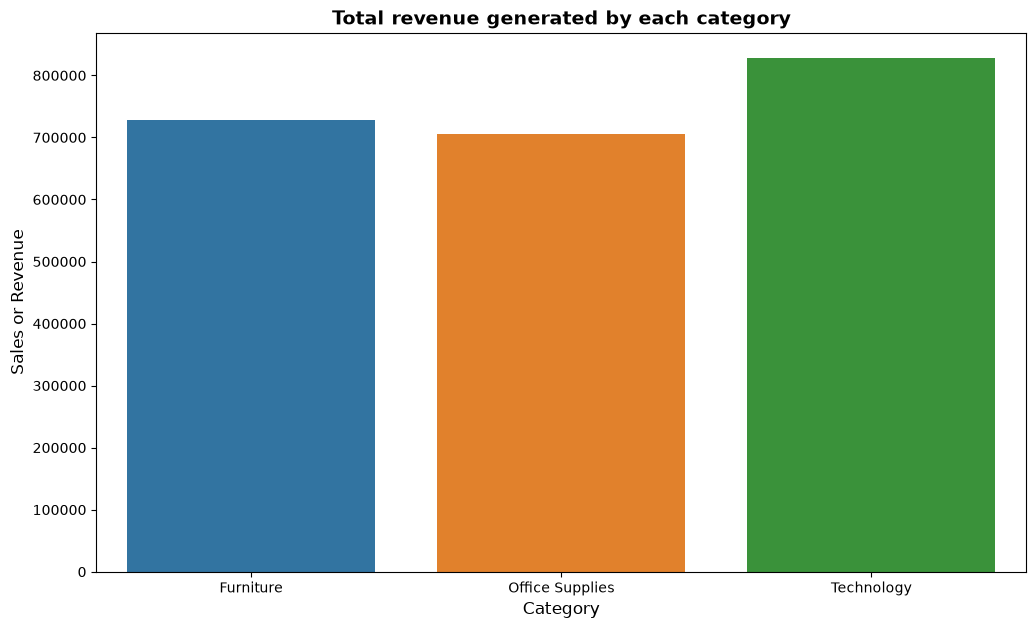

Technology category generates the highest total revenue of 827455.873


In [185]:
# total revenue by category
import seaborn as sns
import matplotlib.pyplot as plt
sales_by_categories = df.groupby(df['Category'])['Sales'].sum()
top_category = sales_by_categories.idxmax()
top_sales_value=sales_by_categories.max()
print(sales_by_categories)

plt.figure(figsize=(12,7))
sns.barplot(x=sales_by_categories.index, y=sales_by_categories.values, hue=sales_by_categories.index, legend=False)
plt.title("Total revenue generated by each category",fontsize=14,fontweight='bold')
plt.xlabel("Category",fontsize=12)
plt.ylabel("Sales or Revenue",fontsize=12)
plt.show()

print(f"{top_category} category generates the highest total revenue of {top_sales_value}")

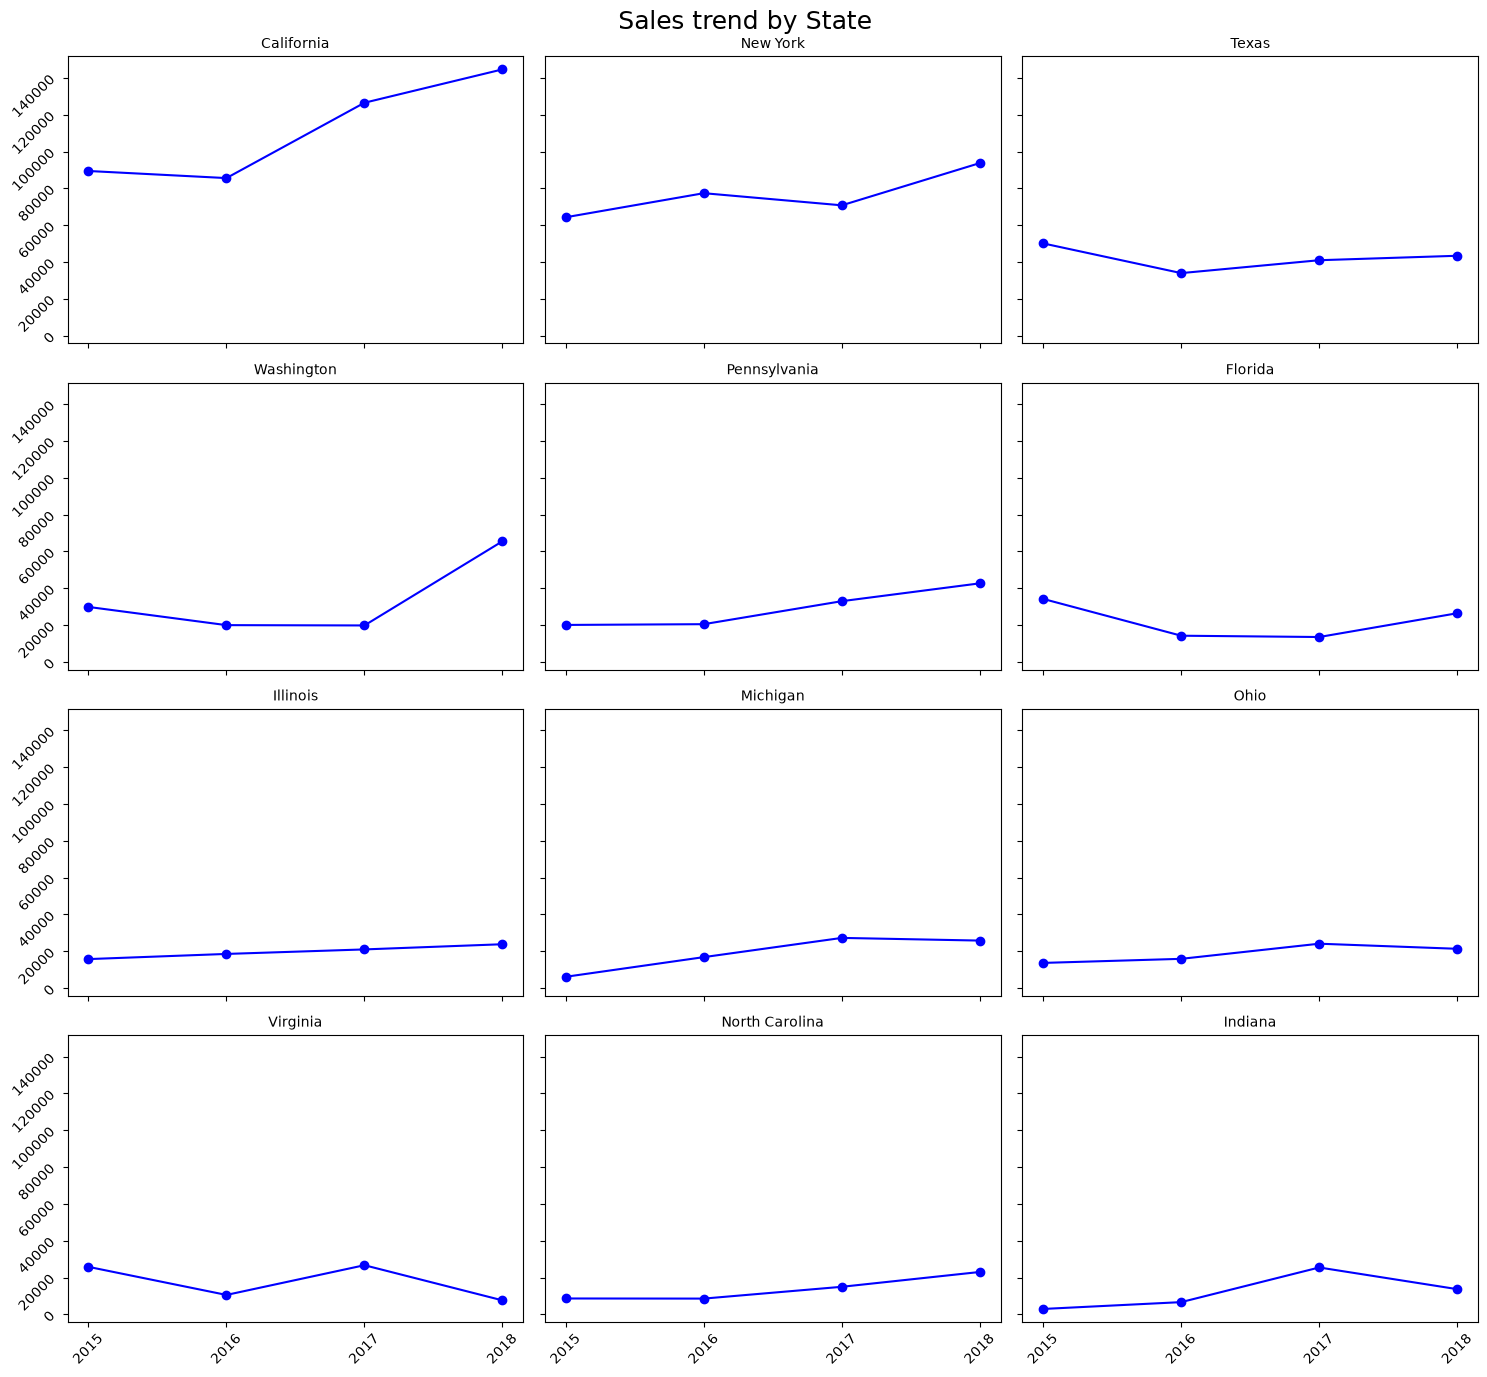

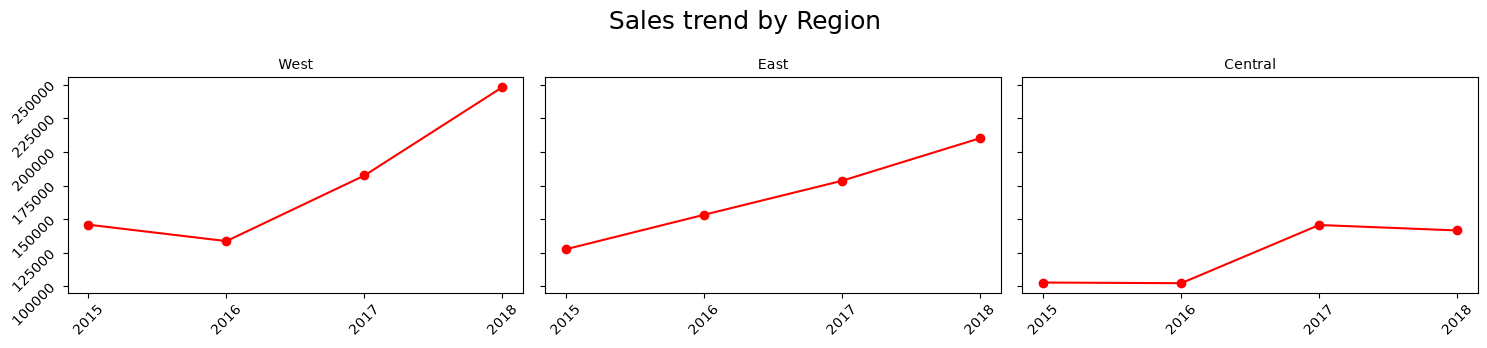

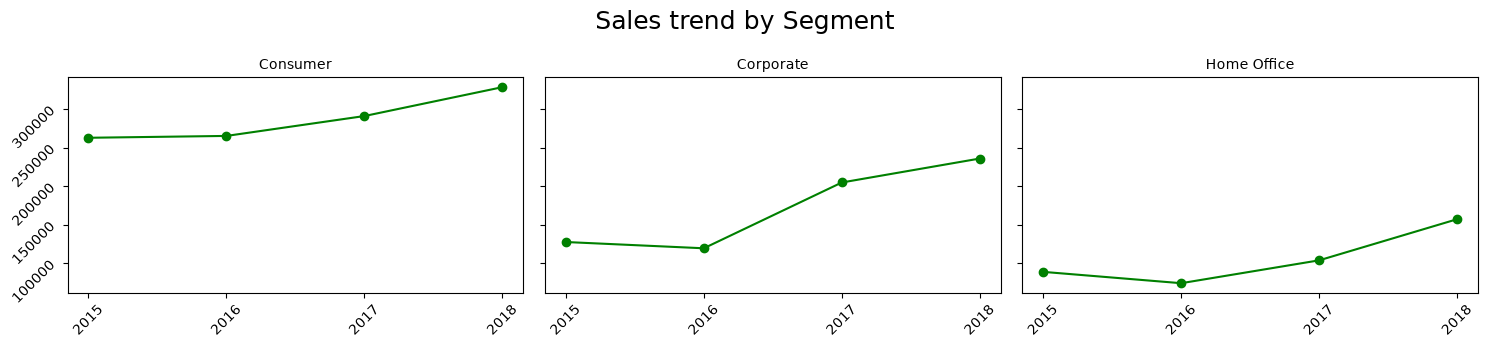

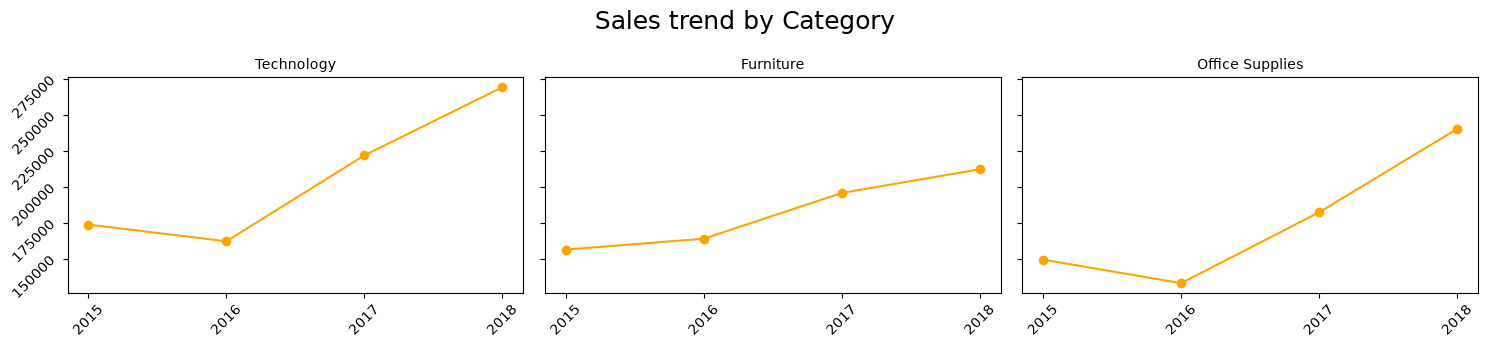

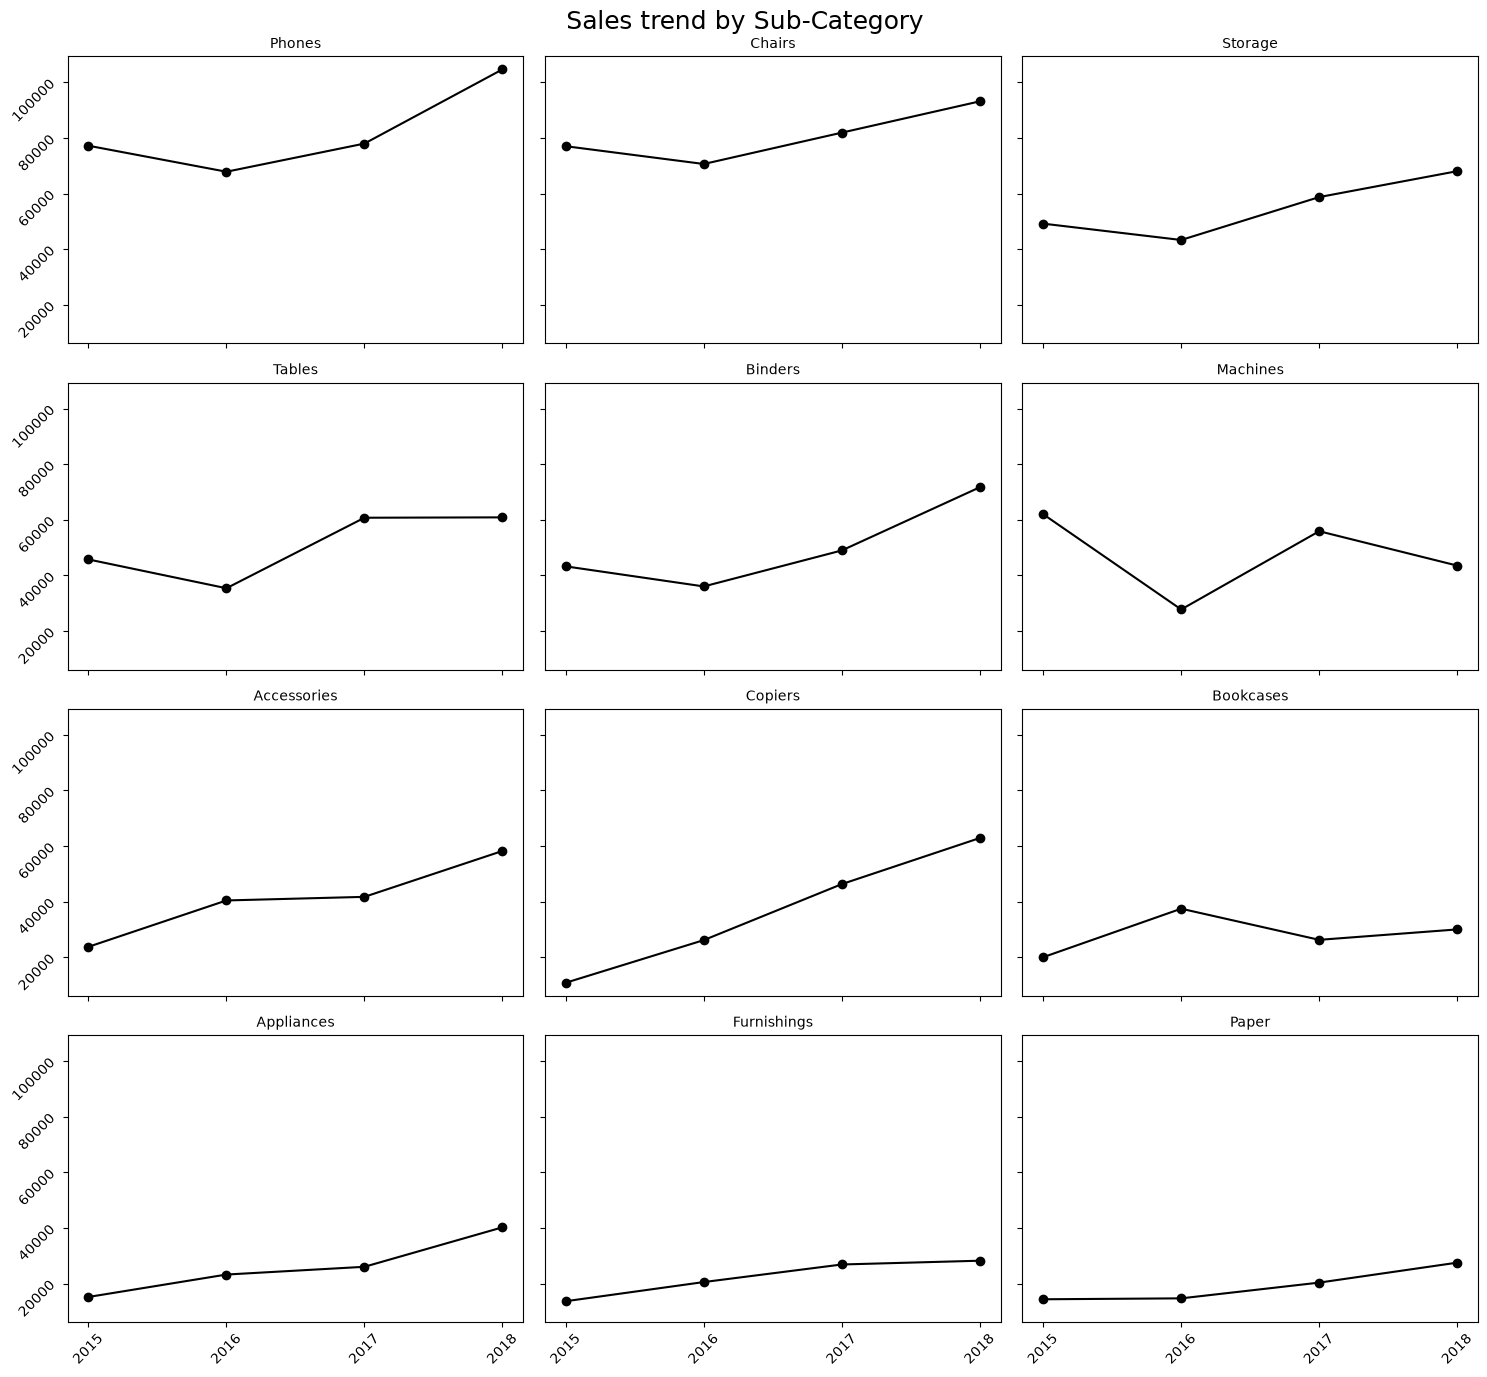

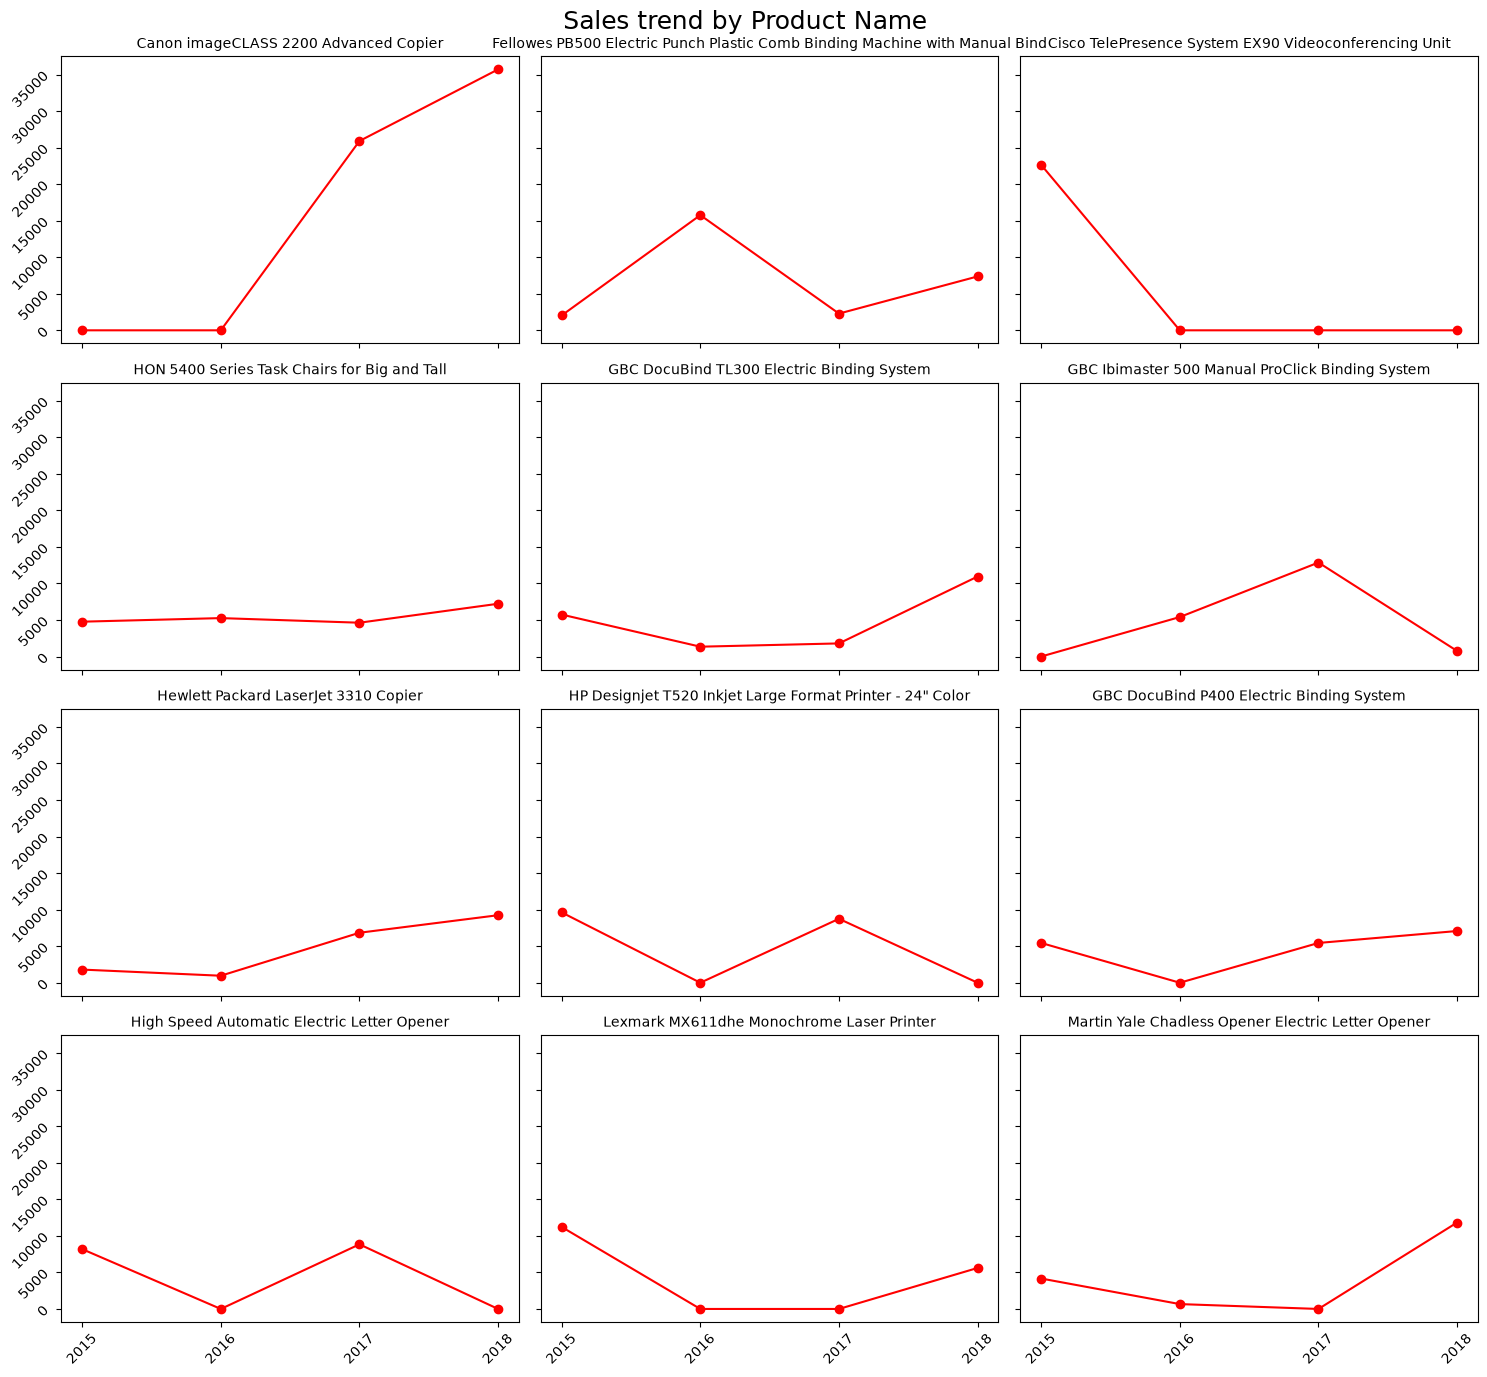

There is a growing and consistent trend of sales in the East region as shown in the red graph


In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import math

def plot_trend_group(group, size, color='blue'):
    # Filter the dataframe to target 4 years only
    target_years = [2015, 2016, 2017, 2018]
    filtered_df = df[df['Order_Year'].isin(target_years)]
    
    # Correctly select and assign the top records
    sales_by_group = filtered_df.groupby(group)['Sales'].sum()
    sales_by_group = sales_by_group.sort_values(ascending=False).head(size) 
    
    # Dynamic row calculation using ceiling division
    num_cols = 3
    num_rows = math.ceil(size / num_cols)
    
    # Create the subplots grid
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 3.5), sharex=True, sharey=True)
    fig.suptitle('Sales trend by {}'.format(group), fontsize=18)
    
    # Ensure axes is always treated as a flat list, even if it's 1-dimensional
    flat_axes = axes.ravel() if hasattr(axes, 'ravel') else [axes]
    
    # Loop over selected groups
    for i, group_name in enumerate(sales_by_group.index):
        ax = flat_axes[i]
        
        # Isolate data for this specific group item
        sales_group = filtered_df[filtered_df[group] == group_name]
        sales_group = sales_group.groupby('Order_Year')['Sales'].sum()
        
        # Ensure all 4 years appear on the X axis, even if sales were 0
        sales_group = sales_group.reindex(target_years, fill_value=0)
        
        # Plotting details
        ax.plot(sales_group.index.astype(str), sales_group.values, color=color, marker='o')
        ax.tick_params(labelrotation=45)
        ax.set_title(group_name, fontsize=10)
        
    # Clean up any empty unused subplot boxes in the grid
    for j in range(size, len(flat_axes)):
        fig.delaxes(flat_axes[j])
        
    fig.tight_layout()
    plt.show()

plot_trend_group('State', 12) # trend per state
plot_trend_group('Region', 3, 'red') # trend per region
plot_trend_group('Segment',3,'green') # trend per segment
plot_trend_group('Category',3, 'orange') # trend per Category
plot_trend_group('Sub-Category',12, 'black') # trend per Sub-Category
plot_trend_group('Product Name',12,'red') # trend per top 12 Product Name

print("There is a growing and consistent trend of sales in the East region as shown in the red graph")

In [187]:
# Ensure both columns are recognized as actual datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Subtract the dates to get a "Timedelta" duration, and extract just the number of days
df['Days_to_Ship'] = (df['Ship Date'] - df['Order Date']).dt.days

# Calculate the true average shipping time
avg_shipping_time = df['Days_to_Ship'].mean()

print(f"There is little to no avg time between order and shipping, with an avg time of {abs(avg_shipping_time):.2f} days.")

There is little to no avg time between order and shipping, with an avg time of 3.96 days.


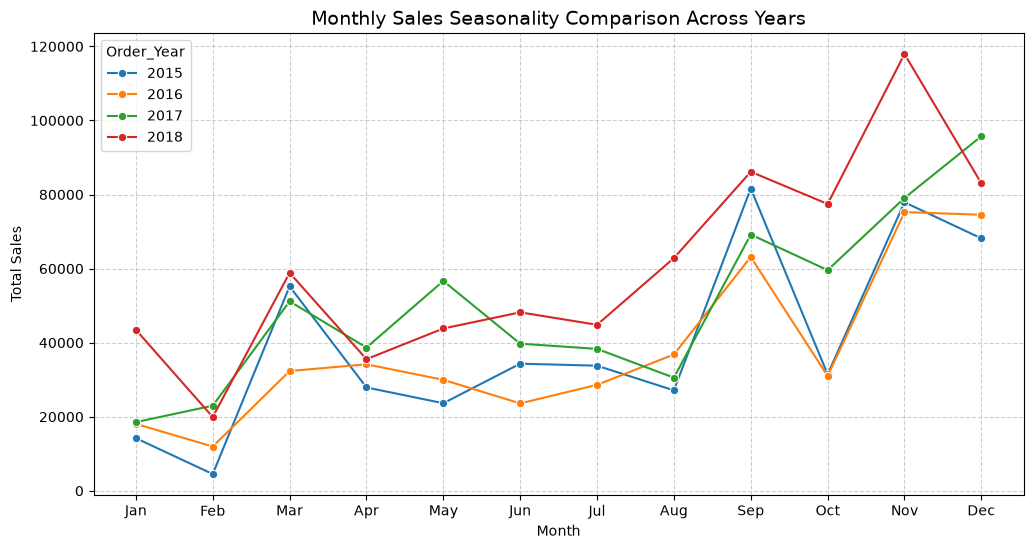

From the graph it is clear that there is seasonality in the data, where there is an increasing trend in March, September and November and decreasing trend in February, August and October


In [188]:
plt.figure(figsize=(12, 6))

# Plot month on X, Sales on Y, and draw a separate line for each Year
monthly_sales = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum().reset_index()
sns.lineplot(data=monthly_sales, x='Order_Month', y='Sales', hue='Order_Year', marker='o', palette='tab10')

plt.title('Monthly Sales Seasonality Comparison Across Years', fontsize=14)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("From the graph it is clear that there is seasonality in the data, where there is an increasing trend in March, September and November and decreasing trend in February, August and October")

## Time Series Analysis & Decomposition
- Plot the overall monthly sales trend across all 4 years
- Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
    - Trend component
    - Seasonal component
    - Residual/noise component
- Plot all 4 components clearly on one figure
- Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? - What months show the highest residual noise?
- Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you
- Apply differencing if the series is non-stationary and re-test


In [189]:
! pip install statsmodels

In [190]:
#sorting data by order date
df.sort_values(by=['Order Date'], inplace=True, ascending=True) #Sorting data by  ascending order of the coloumn values 'Order Date'
df.set_index("Order Date", inplace = True) #Setting 'Order Date' as index of the dataframe 'df' for ease of Time Series Analysis

# the 'Sales' column and 'Order Date' as the index 
simple_df_1 = pd.DataFrame(df['Sales'])
simple_df_1

,Sales
Order Date,
2015-01-03,16.448
2015-01-04,3.540
2015-01-04,272.736
2015-01-04,11.784
2015-01-05,19.536
...,...
2018-12-30,20.720
2018-12-30,323.136
2018-12-30,209.300


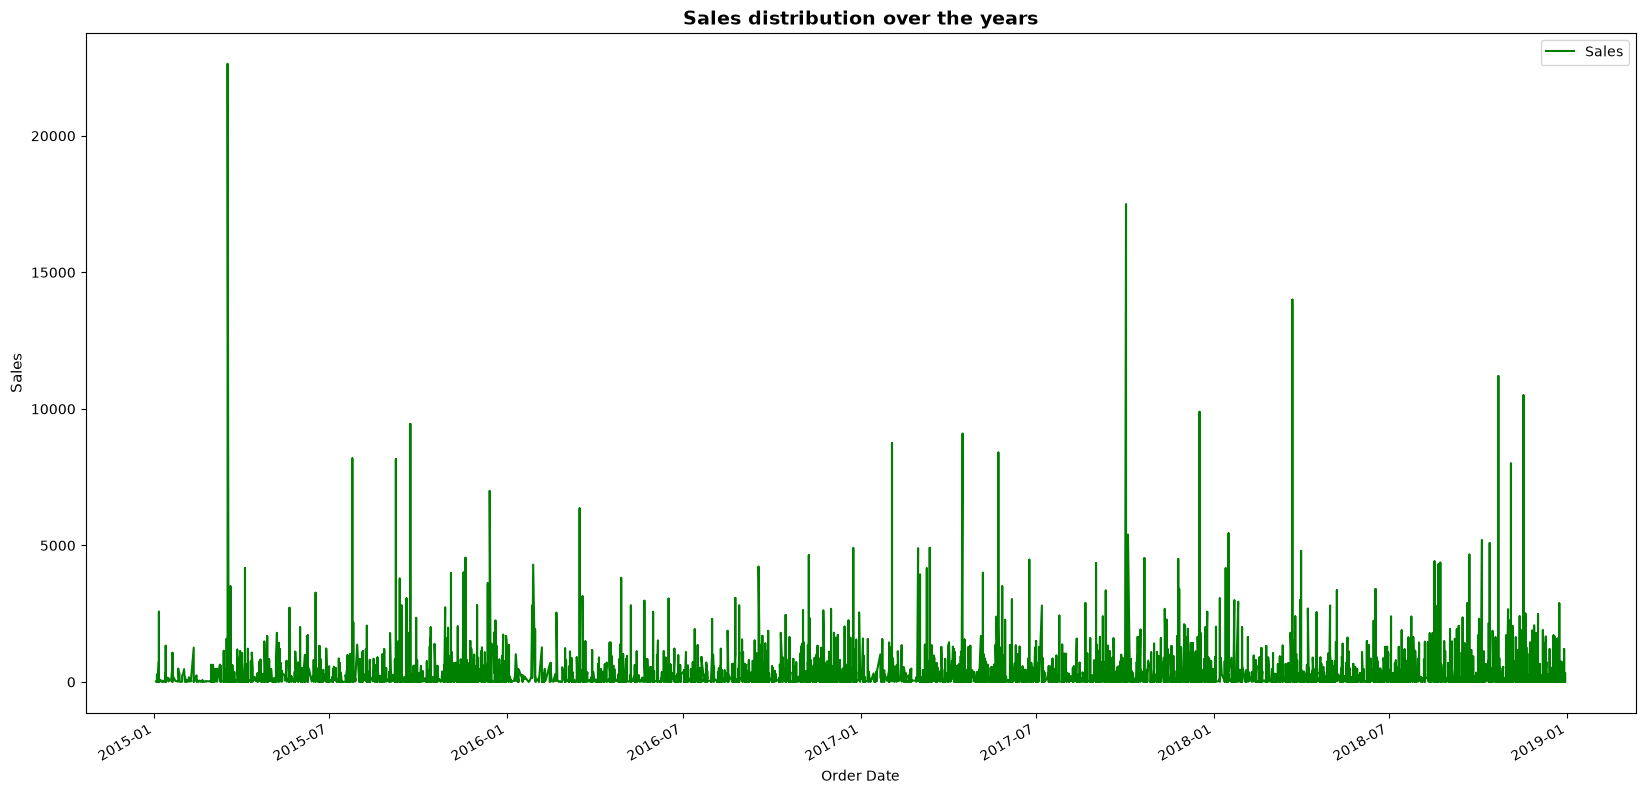

In [191]:
simple_df_1.plot(color='green')
plt.ylabel('Sales',fontsize=11)
plt.title('Sales distribution over the years',fontsize=14,fontweight='bold')
plt.show()

In [192]:
# Checkting for Stationarity
simple_df =  pd.DataFrame(simple_df_1['Sales'].resample('D').mean())

#The interpolate() function is used to interpolate values according to different methods. It ignores the index and treats the values as equally spaced.
simple_df = simple_df.interpolate(method='linear') 

### Data is stationary if the mean and variance of Sales don't change over time

In [193]:
# Method 1: Splitting the data into train, test and validation sets to compare the mean and variance change over time.
train, test, validate = np.split(simple_df['Sales'].sample(frac=1), [int(.6*len(simple_df['Sales'])),int(.8*len(simple_df['Sales']))])

In [194]:
print("-----------------Train data-----------------")
print(train)
print("\n-----------------Test data-----------------")
print(test)
print("\n-----------------Validation data-----------------")
print(validate)

-----------------Train data-----------------
[1.59969429e+02 5.10720000e+01 2.47347000e+02 2.74298500e+02
 1.26524000e+02 9.42754667e+01 2.96442667e+02 3.19255000e+01
 2.80308571e+02 9.79791000e+01 4.34646000e+02 1.37780000e+02
 1.21771667e+02 1.38556909e+02 1.08600000e+01 2.26549077e+02
 2.64008500e+02 1.67127000e+02 1.57302889e+02 4.62511429e+01
 6.64879250e+02 1.21876400e+02 4.17496923e+01 4.86766667e+01
 2.16539667e+02 2.85131765e+02 2.81539000e+02 1.75778667e+02
 3.12738077e+02 3.14988000e+02 2.91100000e+01 1.02636714e+02
 1.07330000e+02 2.05350250e+02 2.81612929e+02 2.59504923e+02
 6.57466667e+01 5.52002895e+02 1.41283556e+02 2.42961167e+02
 4.68812375e+02 1.27715200e+02 2.74150000e+01 8.16162500e+01
 3.96000000e+01 1.50296000e+02 1.70530647e+02 2.75565647e+02
 3.48952000e+01 1.28905000e+01 4.02444250e+02 5.42080000e+01
 1.58390000e+02 1.66464500e+02 2.33400000e+01 1.29350000e+01
 1.33161333e+02 1.21014533e+02 7.47768333e+01 8.87604000e+01
 1.64594000e+02 1.21639143e+02 2.0267200

In [195]:
#taking mean of train, test and validate data
mean1, mean2, mean3 = train.mean(), test.mean(), validate.mean()

#taking variance of train, test and validate data
var1, var2, var3 = train.var(), test.var(), validate.var() 

diff1_mean = mean1-mean2
diff2_mean = mean2-mean3
avg_diff_mean = (diff1_mean+diff2_mean)/2

diff1_var = var1-var2
diff2_var = var2-var3
avg_diff_var = (diff1_var+diff2_var)/2

print(f"Avg difference in mean is: \n{abs(avg_diff_mean)}")
print(f"Avg difference in variance is: \n{abs(avg_diff_var)}")
print(f'Mean:')
print(mean1, mean2, mean3)
print('Variance:')
print(var1, var2, var3)

Avg difference in mean is: 
0.049290175043594786
Avg difference in variance is: 
20374.91606055254
Mean:
223.39140837703218 219.17347009524212 223.292828026945
Variance:
86743.58651858347 53297.40034126317 45993.75439747839


It is certain from the above calculations that there is not so much difference between the mean but there is a certain difference between the variances, necessary for determining the stationarity.

In [196]:
# Method 2: Checking stationarity through ADF (Augmented Dicky Fuller) Test
# Augmented Dickey-Fuller (ADF) test is a statistical test in time series analysis used to determine whether a given time series is stationary. A stationary time series has constant mean and variance over time, which is a core assumption in many time series models, including ARIMA.
from statsmodels.tsa.stattools import adfuller

adf = adfuller(simple_df) 

print(adf)
print(f'\nADF = {(adf[0])}') #more towards negative value the better
print(f'\np-value = {adf[1]}')
print('\nCritical Values: ')

for key, val in adf[4].items(): #for loop to print the p-value (1%, 5% and 10%) and their respective values
    print(key,':',val)
    if adf[0] < val:
        print('Null Hypothesis Rejected. Time Series is Stationary')
    else:
        print('Null Hypothesis Accepted. Time Series is not Stationary')

(np.float64(-20.80945851483934), 0.0, 2, 1455, {'1%': np.float64(-3.4348523191002123), '5%': np.float64(-2.8635284734563364), '10%': np.float64(-2.567828646449617)}, np.float64(20042.15494613892))

ADF = -20.80945851483934

p-value = 0.0

Critical Values: 
1% : -3.4348523191002123
Null Hypothesis Rejected. Time Series is Stationary
5% : -2.8635284734563364
Null Hypothesis Rejected. Time Series is Stationary
10% : -2.567828646449617
Null Hypothesis Rejected. Time Series is Stationary


### From ADF test it is proved that the data is stationary

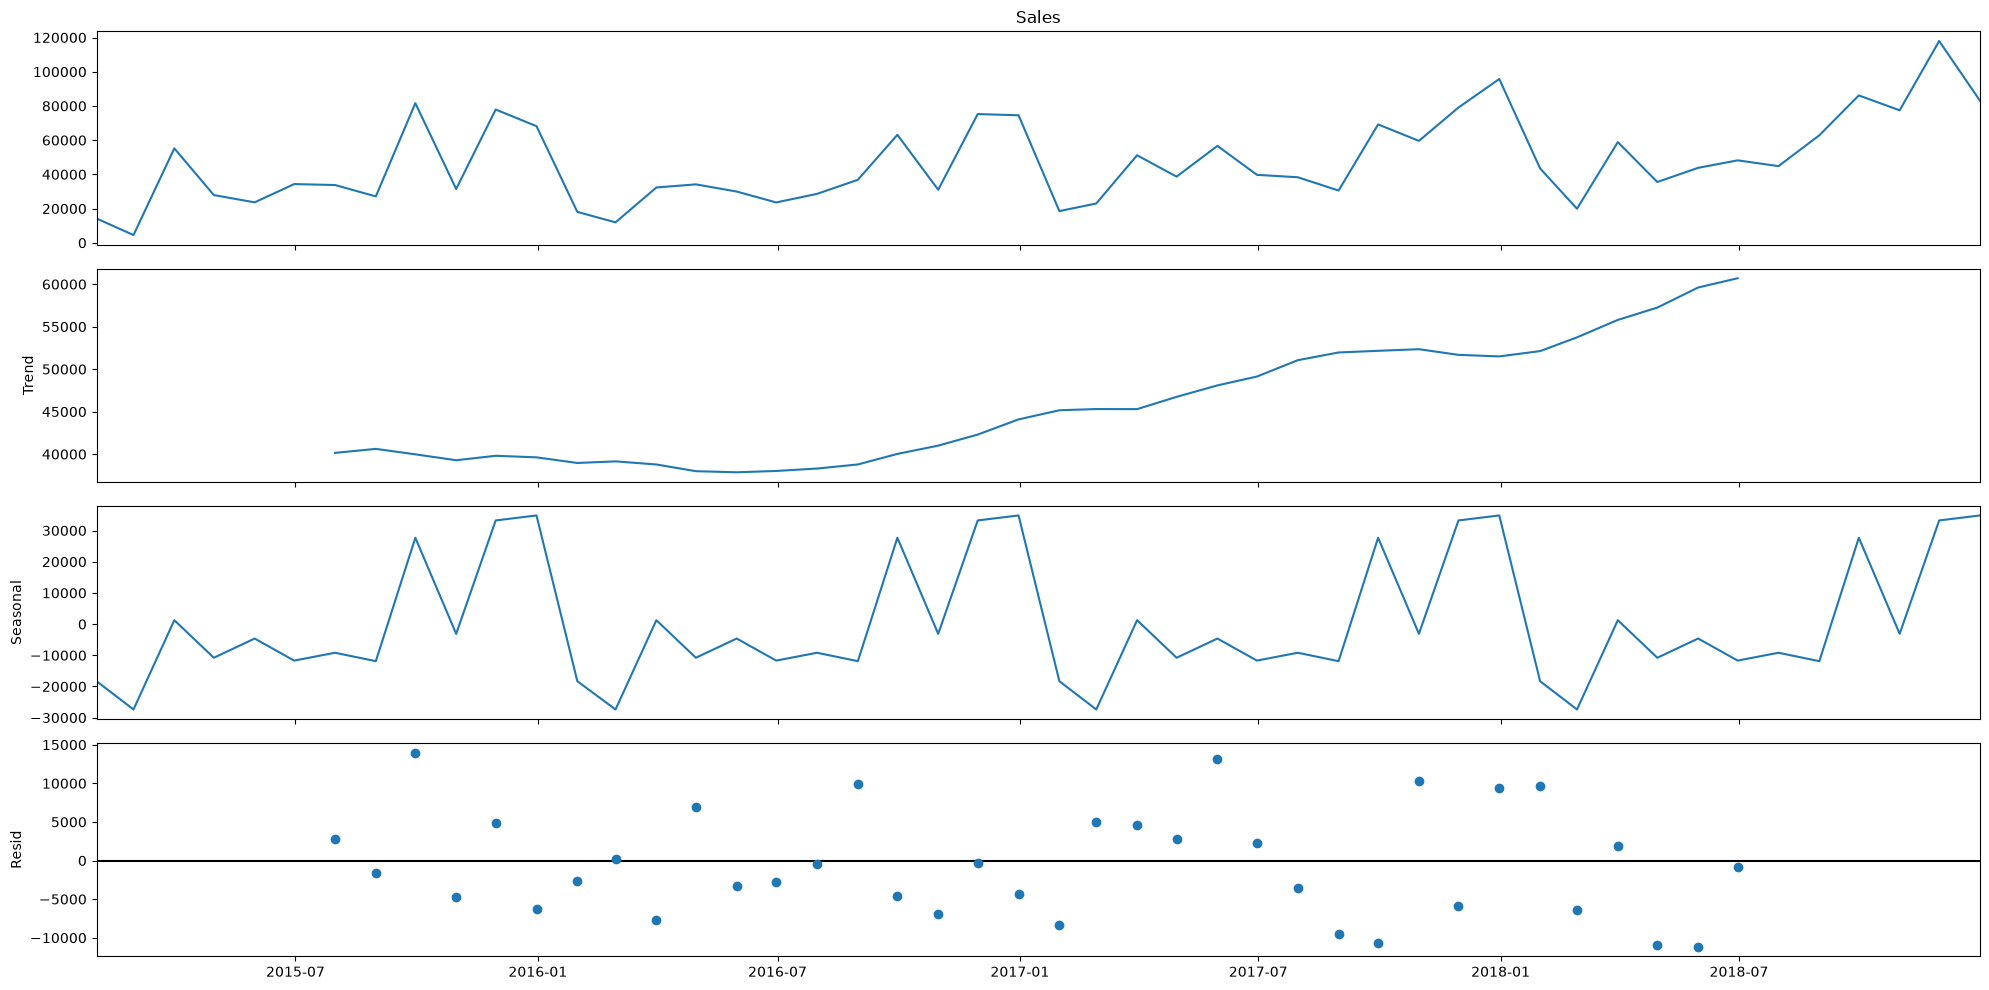

In [197]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pylab import rcParams

rcParams['figure.figsize'] = 20, 10
# plotting seasonal decomposition in monthly ends
monthly_sales = df['Sales'].resample('ME').sum()
decomposition = sm.tsa.seasonal_decompose(monthly_sales, model='additive', period=12) 
fig = decomposition.plot()
plt.show();

From the seasonal decomposition plot it can be seen that the time series data is **stationary** and there is a strict, strong pattern in seasonality, from early 2015 to mid 2016, sales were relatively stagnant, around July 2016 an increasing trend can be seen upto July 2018 indicating healthy business expansion, the outliers or some certain data points spike between July and January interval of two years  at certain point. The highest spike can be noticed between July 2015 and January 2016. 

There is no need to calculate differencing here as the data is already stationary.

## Sales Forecasting using 3 Different Models
- This is the core technical task. Build, train, and compare 3 fundamentally different forecasting approaches:
    - Model 1 — SARIMA (Statistical Model)
    - Install statsmodels (pip install statsmodels)
    - Fit a SARIMA model on monthly sales
    - Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them
    - Generate a 3-month future forecast with confidence intervals
    - Plot actual vs forecasted sales
    - Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)
        - Install Prophet (pip install prophet)
        - Prepare data in Prophet's required format (ds, y columns)
        - Fit the model and generate a 3-month forecast
        - Plot the forecast with Prophet's built-in trend and seasonality breakdown
        - Extract and interpret the weekly and yearly seasonality components
    - Model 3 — XGBoost for Time Series (ML-based Approach)
    - Convert the time series into a supervised ML problem using lag features:
        - Lag 1 (sales from 1 month ago)
        - Lag 2 (sales from 2 months ago)
        - Lag 3 (sales from 3 months ago)
    - Rolling mean (3-month moving average)
    - Month, Quarter, Season as features
    - Train XGBoost Regressor on these features
    - Predict the next 3 months
    - Plot actual vs predicted


In [198]:
! pip install pmdarima

In [199]:
import pmdarima as pm

monthly_sales = df['Sales'].resample('ME').sum()

# Run auto_arima with daily seasonality (m=12)
auto_model = pm.auto_arima(
    monthly_sales,
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True
)

# View best model details
print("Best SARIMA model:", auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1079.923, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1096.560, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1076.500, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1077.487, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1094.708, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1089.579, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1078.250, Time=0.07 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1078.452, Time=0.07 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1080.901, Time=0.05 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1079.864, Time=0.14 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1084.035, Time=0.03 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1073.635, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1087.151, Time=0.02 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1075.267, Time=0.10 sec
 ARIMA(2,1,0)(1,0,1

1. The Chosen Model Structure (The Top Left)

Look at the very first line: Best model: ARIMA(2,1,0)(1,0,0)

- What it tells us: Despite the data passing a stationarity test earlier, auto_arima actually mathematically determined that our data was not fully stationary.

- The breakdown: It chose d=1 (regular differencing) to flatten out that long-term climbing trend we saw, but kept D=0 (no seasonal differencing), opting instead to capture the December waves using a seasonal autoregressive term (P=1). It found the optimal balance for you automatically.

2. Parameter Significance: The P-Values (The Middle Table)

Look at the P>|z| column. Just like any statistical test, we want these values to be less than 0.05 to prove that specific component is actually helpful.

- ar.L1 (p = 0.005): Highly Important. This is below 0.05, meaning last month's sales are a statistically significant predictor of this month's sales.

- ar.L2 (p = 0.259): Not Significant. This is above 0.05. It means looking back two months doesn't add any real predictive value over just looking back one month. Don't worry—auto_arima keeps it because removing it might hurt the overall math, but it's good to note it's weak.

- ar.S.L12 (p = 0.000): Extremely Important. This is our seasonal anchor term. A p-value of 0.000 means the 12-month repeating pattern (the holiday spikes) is a massive, mathematically undeniable driver of our forecasts.

3. Residual Diagnostics: The "Pass/Fail" Tests (The Bottom Box)

This is where we check if our leftovers are pure random noise. Look specifically at the Prob values:

- Ljung-Box Prob(Q) = 0.69: PASS. We want this number to be greater than 0.05. Since it's 0.69, it proves that our residuals are completely random, meaning our model successfully captured all the historical patterns. No information was left on the table.

- Jarque-Bera Prob(JB) = 0.34: PASS. We want this number to be greater than 0.05. This proves that our forecasting errors are normally distributed (following a standard bell curve), meaning our confidence intervals for our 3-month forecast will be mathematically trustworthy.

### Summary Verdict

Our model is in excellent shape. The seasonal term is incredibly strong (p = 0.000), and both diagnostic checks (Prob(Q) and Prob(JB)) passed with flying colors by staying well above 0.05.

In [200]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# initializing SARIMAX model
sari_model = SARIMAX(
    monthly_sales,
    order=auto_model.order,
    seasonal_order=auto_model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results = sari_model.fit()
forecast_steps = 3 # for three months
forecast_obj = sarima_results.get_forecast(steps=forecast_steps)
forecast_mean = forecast_obj.predicted_mean
confidence_intervals = forecast_obj.conf_int()

# Build forecast DataFrame
sarima_output = pd.DataFrame({
    'Date': pd.date_range(start=monthly_sales.index[-1], periods=forecast_steps+1, freq='ME')[1:],
    'Predicted Sales': forecast_mean.values,
    'Lower Bound': confidence_intervals.iloc[:, 0].clip(lower=0).values,
    'Upper Bound': confidence_intervals.iloc[:, 1].values
})

# Add average row
avg_row = pd.DataFrame({
    'Date': ['Average'],
    'Predicted Sales': [round(sarima_output['Predicted Sales'].mean(), 2)],
    'Lower Bound': [None],
    'Upper Bound': [None]
})

sarima_output = pd.concat([sarima_output, avg_row], ignore_index=True)

# Display the forecast
print("3-Months Sales Forecast (SARIMA):")
display(sarima_output)

# # Print the clear numerical results for business report
# print("--- 3-MONTH FUTURE FORECAST ---")
# for date, value in forecast_mean.items():
#     # Clean up the output string to avoid raw np.float64 text
#     print(f"{date.strftime('%Y-%B')}: {float(value):,.2f}")

# print("\n--- CONFIDENCE INTERVALS ---")
# print(confidence_intervals)

3-Months Sales Forecast (SARIMA):


,Date,Predicted Sales,Lower Bound,Upper Bound
0,2019-01-31 00:00:00,65162.359837,20224.514243,110100.205432
1,2019-02-28 00:00:00,48808.257097,2574.924254,95041.58994
2,2019-03-31 00:00:00,66799.319915,17959.212905,115639.426925
3,Average,60256.650000,None,None


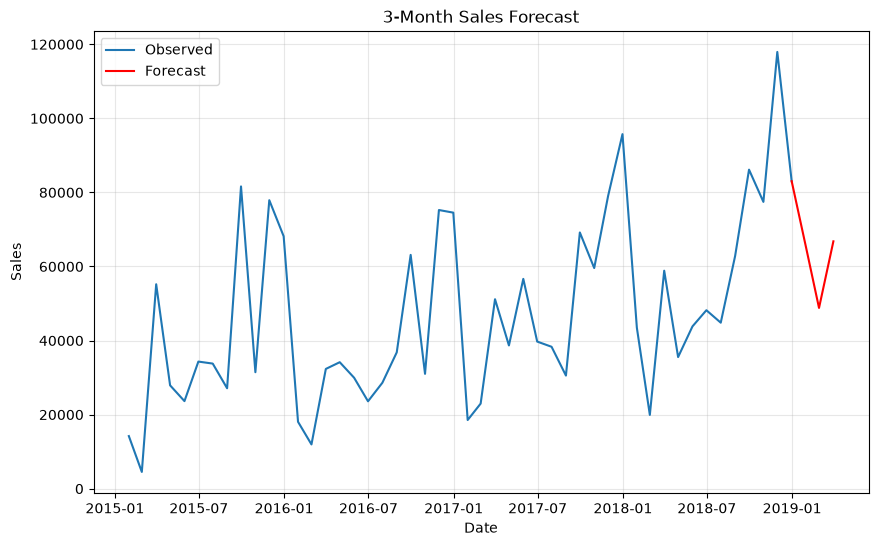

In [201]:
forecast_periods = 3
forecast = sarima_results.forecast(steps=forecast_periods)

plt.figure(figsize=(10, 6))
# Plot the historical observed data
plt.plot(monthly_sales.index, monthly_sales, label='Observed')

# Append the last historical point to the forecast to bridge the visual gap
connect_index = monthly_sales.index[-1:]
connect_value = monthly_sales.iloc[-1:]

extended_forecast_index = connect_index.append(forecast.index)
extended_forecast_values = pd.concat([connect_value, forecast])

# 3. Plot the connected forecast line
plt.plot(extended_forecast_index, extended_forecast_values, label='Forecast', color='red')

plt.title("3-Month Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True, alpha=0.3) # Adds a clean background grid for easier reading
plt.legend()
plt.show()

In [202]:
! pip install prophet

16:02:26 - cmdstanpy - INFO - Chain [1] start processing
16:02:27 - cmdstanpy - INFO - Chain [1] done processing


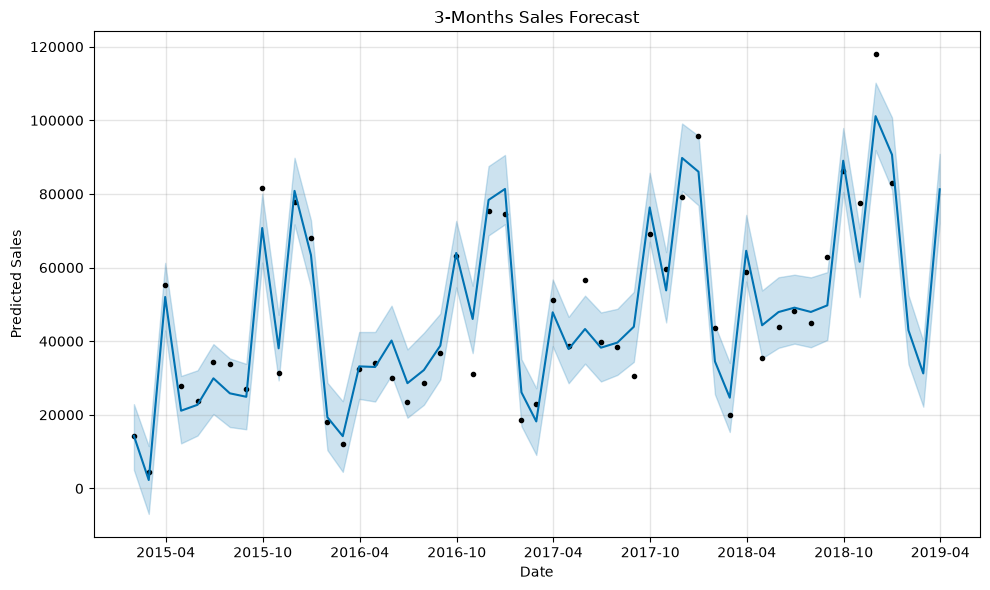

In [203]:
# Import Prophet
from prophet import Prophet

# Rename columns to match Prophet's expected input
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ['ds', 'y']  # ds = date, y = value to forecast

# Initialize and fit the Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
prophet_model.fit(prophet_df)

# Create future dataframe for next 3 Months
future = prophet_model.make_future_dataframe(periods=3,freq='ME')
forecast = prophet_model.predict(future)

# Plot forecast
prophet_model.plot(forecast)
plt.title("3-Months Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.tight_layout()
plt.show()

In [204]:
import warnings
warnings.filterwarnings("ignore")
# Get last date in original dataset
last_date = prophet_df['ds'].max()

# Filter only the next 3 months
future_forecast = forecast[forecast['ds'] > last_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()

# Rename columns for clarity
future_forecast.rename(columns={
    'ds': 'Date',
    'yhat': 'Predicted Sales',
    'yhat_lower': 'Lower Bound',
    'yhat_upper': 'Upper Bound'
}, inplace=True)

# Calculate average predicted sales
avg_sales = future_forecast['Predicted Sales'].mean()

# Create a new row for the average
average_row = pd.DataFrame({
    'Date': ['Average'],
    'Predicted Sales': [round(avg_sales, 2)],
    'Lower Bound': [None],
    'Upper Bound': [None]
})

# Append the row to the forecast DataFrame
forecast_with_avg = pd.concat([future_forecast, average_row], ignore_index=True)

# Display
print("3-Months Sales Forecast with Average:")
display(forecast_with_avg)

3-Months Sales Forecast with Average:


,Date,Predicted Sales,Lower Bound,Upper Bound
0,2019-01-31 00:00:00,42990.53220,33811.861202,52481.446239
1,2019-02-28 00:00:00,31248.15992,22210.943385,40035.825387
2,2019-03-31 00:00:00,81267.00777,72062.743744,90906.305281
3,Average,51835.23000,None,None


In [205]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
actual = np.array(monthly_sales[-3:])
prop_preds = np.array(forecast_with_avg['Predicted Sales'][0:3])
print(mean_absolute_error(actual,prop_preds))
print(mean_absolute_percentage_error(actual,prop_preds))
print(root_mean_squared_error(actual,prop_preds))
print(forecast_with_avg['Predicted Sales'][0])

40970.32503699803
0.40039864942331166
53868.94865802905
42990.532199773515


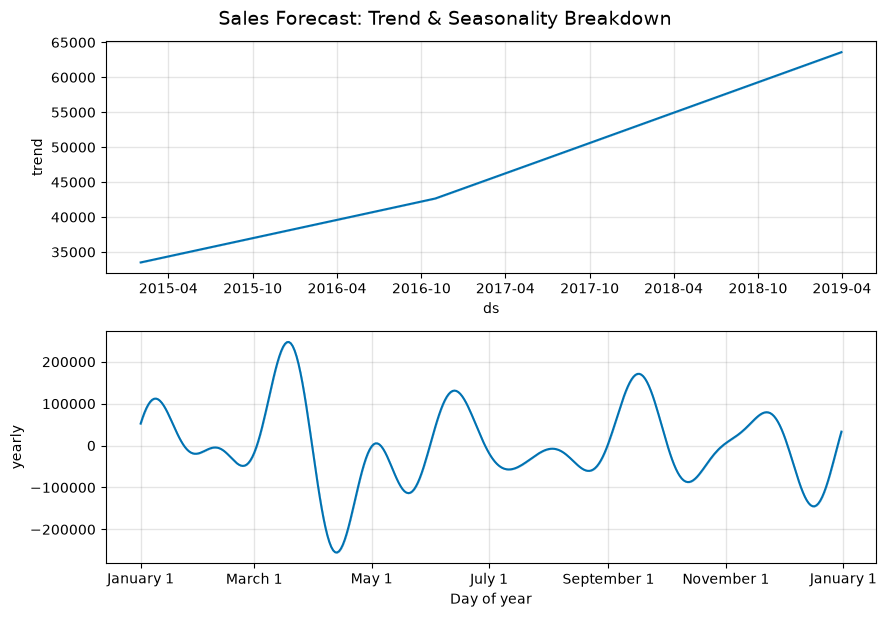

--- NUMERICAL YEARLY SEASONAL IMPACT ---
Month
January     -19099.297385
February    -28994.452056
March         8036.422312
April       -10261.751844
May          -6393.944199
June         -9032.704949
July         -9698.779389
August       -7343.346561
September    27767.465607
October       2030.069163
November     39043.552068
December     31212.283178
Name: yearly, dtype: float64


In [206]:
# Plot Prophet's built-in breakdown (Trend and Yearly Seasonality)
fig_components = prophet_model.plot_components(forecast)
fig_components.suptitle("Sales Forecast: Trend & Seasonality Breakdown", y=1.02, fontsize=14)
plt.show()

# Extract the raw underlying yearly seasonality numbers
# Prophet stores seasonal effects in the forecast dataframe under 'yearly'
yearly_component = forecast[['ds', 'yearly']].copy()

# Group by month to see the average seasonal impact per calendar month
yearly_component['Month'] = yearly_component['ds'].dt.strftime('%B')
monthly_seasonality_summary = yearly_component.groupby('Month')['yearly'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
])

print("--- NUMERICAL YEARLY SEASONAL IMPACT ---")
print(monthly_seasonality_summary)

In [207]:
# Convert Series to DataFrame
ml_df = pd.DataFrame(monthly_sales.copy())
ml_df.columns = ['Sales']

# Create Lag Features (Past performance)
ml_df['Lag_1'] = ml_df['Sales'].shift(1) # 1 month ago
ml_df['Lag_2'] = ml_df['Sales'].shift(2) # 2 months ago
ml_df['Lag_3'] = ml_df['Sales'].shift(3) # 3 months ago

# Create Rolling Features (Smooth moving averages)
# We shift by 1 first so the rolling mean doesn't include the current month's target
ml_df['Rolling_Mean'] = ml_df['Sales'].shift(1).rolling(window=3).mean()

# Create Calendar Features
ml_df['Month'] = ml_df.index.month
ml_df['Quarter'] = ml_df.index.quarter

# Helper function to map months to seasons
def get_season(month):
    if month in [12, 1, 2]: return 1  # Winter
    elif month in [3, 4, 5]: return 2 # Spring
    elif month in [6, 7, 8]: return 3 # Summer
    else: return 4                    # Fall

ml_df['Season'] = ml_df['Month'].apply(get_season)

# Drop rows with NaN values created by the lags
ml_df_clean = ml_df.dropna()

print(ml_df_clean.head())

                 Sales       Lag_1       Lag_2      Lag_3  Rolling_Mean  \
Order Date                                                                
2015-04-30  27906.8550  55205.7970   4519.8920  14205.707  24643.798667   
2015-05-31  23644.3030  27906.8550  55205.7970   4519.892  29210.848000   
2015-06-30  34322.9356  23644.3030  27906.8550  55205.797  35585.651667   
2015-07-31  33781.5430  34322.9356  23644.3030  27906.855  28624.697867   
2015-08-31  27117.5365  33781.5430  34322.9356  23644.303  30582.927200   

            Month  Quarter  Season  
Order Date                          
2015-04-30      4        2       2  
2015-05-31      5        2       2  
2015-06-30      6        2       3  
2015-07-31      7        3       3  
2015-08-31      8        3       3  


In [208]:
ml_df_clean.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,2
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,2
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,3
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,3
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,3


In [209]:
# separating the features and target
X = ml_df_clean.drop(columns='Sales')
y = ml_df_clean['Sales']

In [210]:
from sklearn.model_selection import train_test_split

# splitting the data in train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [211]:
! pip install xgboost

In [212]:
import xgboost as xgb
# initialize the model
xg_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=3, early_stopping_rounds=50)
xg_model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_test,y_test)], verbose=50)

[0]	validation_0-rmse:22150.07442	validation_1-rmse:29565.67439
[50]	validation_0-rmse:8828.86729	validation_1-rmse:18106.13820
[100]	validation_0-rmse:4917.82185	validation_1-rmse:16562.24819
[150]	validation_0-rmse:3409.05470	validation_1-rmse:16003.61454
[200]	validation_0-rmse:2400.55807	validation_1-rmse:15650.29926
[250]	validation_0-rmse:1798.11968	validation_1-rmse:15584.11657
[300]	validation_0-rmse:1378.84784	validation_1-rmse:15555.21626
[350]	validation_0-rmse:1001.35338	validation_1-rmse:15547.51317
[374]	validation_0-rmse:873.85407	validation_1-rmse:15532.52645


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [213]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# 1. Grab the very last row of actual clean dataset
last_historical_date = monthly_sales.index[-1]
current_sales_history = list(monthly_sales.values[-3:]) # Keeps track of the last 3 actual months

# 2. Setup storage for our future predictions
future_dates = pd.date_range(start=last_historical_date, periods=4, freq='ME')[1:]
predictions = []

# 3. Run the Recursive Loop for exactly 3 months
for i, estimate_date in enumerate(future_dates):
    # Extract calendar features dynamically based on the target month
    m = estimate_date.month
    q = (m - 1) // 3 + 1
    
    # Season mapping
    if m in [12, 1, 2]: s = 1
    elif m in [3, 4, 5]: s = 2
    elif m in [6, 7, 8]: s = 3
    else: s = 4
    
    # Reconstruct the exact feature row layout your model was trained on
    lag1 = current_sales_history[-1]
    lag2 = current_sales_history[-2]
    lag3 = current_sales_history[-3]
    rolling_3m = np.mean([lag1, lag2, lag3])
    
    # Create the X input array
    X_next = pd.DataFrame([{
        'Lag_1': lag1,
        'Lag_2': lag2,
        'Lag_3': lag3,
        'Rolling_Mean': rolling_3m,
        'Month': m,
        'Quarter': q,
        'Season': s
    }])
    
    # Predict the next month
    pred = xg_model.predict(X_next)[0]
    predictions.append(pred)
    
    # CRITICAL: Append the new prediction into our history so the NEXT loop can use it as a lag!
    current_sales_history.append(pred)

# 4. Build the final clean output DataFrame
xgboost_forecast = pd.DataFrame({
    'Date': future_dates,
    'XGBoost_Predicted_Sales': predictions
}).set_index('Date')

print(xgboost_forecast)

            XGBoost_Predicted_Sales
Date                               
2019-01-31             43917.550781
2019-02-28             21472.242188
2019-03-31             44302.378906


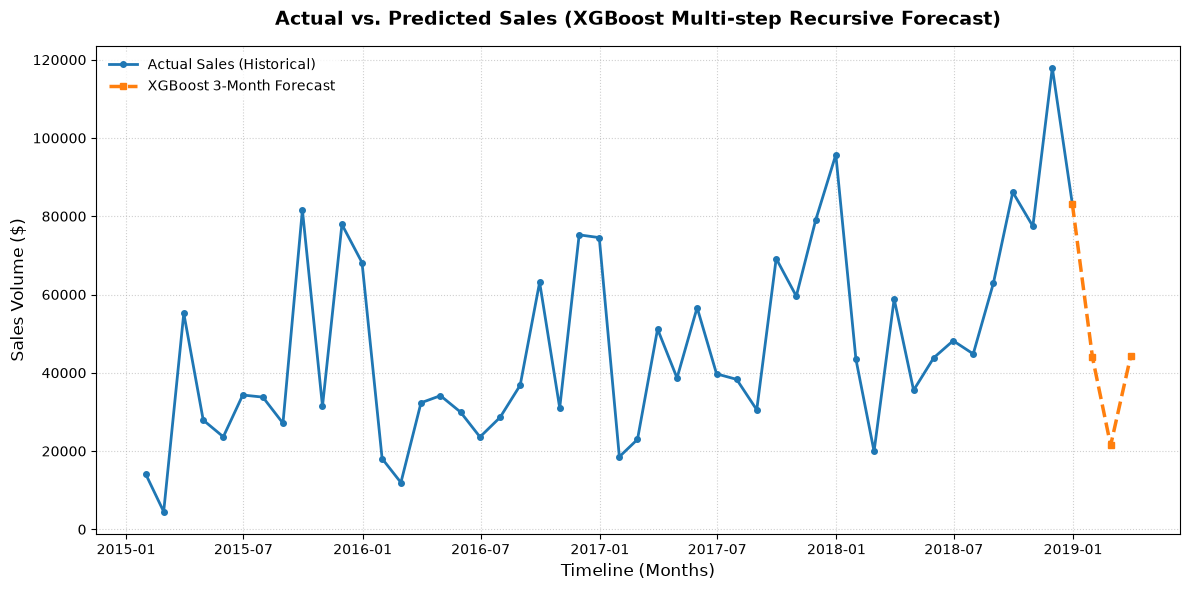

In [214]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup the plotting canvas
plt.figure(figsize=(12, 6))

# 2. Plot the historical actual data (Observed sales)
plt.plot(
    monthly_sales.index, 
    monthly_sales.values, 
    label='Actual Sales (Historical)', 
    color='#1f77b4', 
    linewidth=2, 
    marker='o', 
    markersize=4
)

# 3. Connect the forecast seamlessly to the last historical point
# We create a small 1-row DataFrame of the last actual point to bridge the visual gap
bridge_df = pd.DataFrame(
    {'XGBoost_Predicted_Sales': [monthly_sales.values[-1]]}, 
    index=[monthly_sales.index[-1]]
)

# Combine the bridge point with your future predictions dataframe
full_forecast = pd.concat([bridge_df, xgboost_forecast])

# 4. Plot the predicted data line
plt.plot(
    full_forecast.index, 
    full_forecast['XGBoost_Predicted_Sales'], 
    label='XGBoost 3-Month Forecast', 
    color='#ff7f0e', 
    linewidth=2.5, 
    linestyle='--', 
    marker='s', 
    markersize=5
)

# 5. Polish the chart aesthetics for business presentations
plt.title("Actual vs. Predicted Sales (XGBoost Multi-step Recursive Forecast)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline (Months)", fontsize=12)
plt.ylabel("Sales Volume ($)", fontsize=12)

# Format the grid lines cleanly
plt.grid(True, linestyle=':', alpha=0.6)

# Place the legend in an empty location automatically
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# Clean layout spacing
plt.tight_layout()
plt.show()

In [215]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error

# actual historical sales
actual = np.array(monthly_sales[-3:])

# future predictions or forecasts from all three models
prop_preds = np.array(forecast_with_avg['Predicted Sales'][0:3])
xgboost_preds = np.array(xgboost_forecast['XGBoost_Predicted_Sales'])
sarima_preds = np.array(sarima_output['Predicted Sales'][0:3])

# models column
models = ['SARIMA', 'Prophet', 'XGBoost']

# metric dictionary
metric_dict = {'MAE':[mean_absolute_error(actual,sarima_preds),mean_absolute_error(actual,prop_preds),mean_absolute_error(actual,xgboost_preds)],
               'MAPE':[mean_absolute_percentage_error(actual,sarima_preds)*100,mean_absolute_percentage_error(actual,prop_preds)*100,mean_absolute_percentage_error(actual,xgboost_preds)*100],
              'RMSE':[root_mean_squared_error(actual,sarima_preds),root_mean_squared_error(actual,prop_preds),root_mean_squared_error(actual,xgboost_preds)],
              'Month 1':[sarima_preds[0],prop_preds[0],xgboost_preds[0]],
              'Month 2':[sarima_preds[1],prop_preds[1],xgboost_preds[1]],
              'Month 3':[sarima_preds[2],prop_preds[2],xgboost_preds[2]],
              'Models':models}

# rounding off to two decimals for each value
metric_dict_rounded = {key:np.round(value,2) if key!='Models' else value for key,value in metric_dict.items()}

# metrics dataframe
metric_df = pd.DataFrame(metric_dict_rounded)
metric_df.set_index('Models',inplace=True)
metric_df

,MAE,MAPE,RMSE,Month 1,Month 2,Month 3
Models,,,,,,
SARIMA,32548.91,31.34,41606.61,65162.36,48808.26,66799.32
Prophet,40970.33,40.04,53868.95,42990.53,31248.16,81267.01
XGBoost,56241.50,57.24,63060.37,43917.55,21472.24,44302.38


Our metric table clearly states that **SARIMA** is the winnner here with the lowest mean absolute error, root mean squared error and mean absolute percentage error. 

## Product Category & Region Level Forecasting
- Repeat the best performing model (from Task 3) separately for each of the following segments:
    - Furniture category sales
    - Technology category sales
    - Office Supplies category sales
    - West region sales
    - East region sales
- Plot all 5 forecasts together on one comparison chart
- Write: which category/region is showing the strongest upcoming growth according to your model?

In [216]:
req_df = df[["Region","Category","Sales"]]

In [217]:
print(req_df['Region'].value_counts())
print(req_df['Category'].value_counts())

Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64
Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64


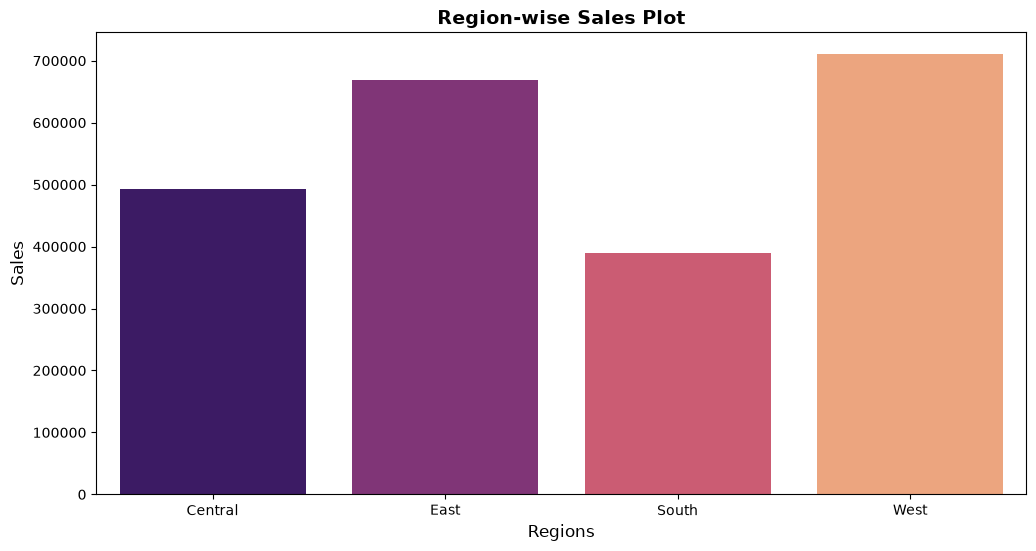

In [218]:
import matplotlib.pyplot as plt
import seaborn as sns

regionwise_sales = req_df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(12,6))
sns.barplot(regionwise_sales,palette='magma')
plt.title("Region-wise Sales Plot",fontsize=14, fontweight='bold')
plt.xlabel("Regions",fontsize=12)
plt.ylabel("Sales",fontsize=12)
plt.show()

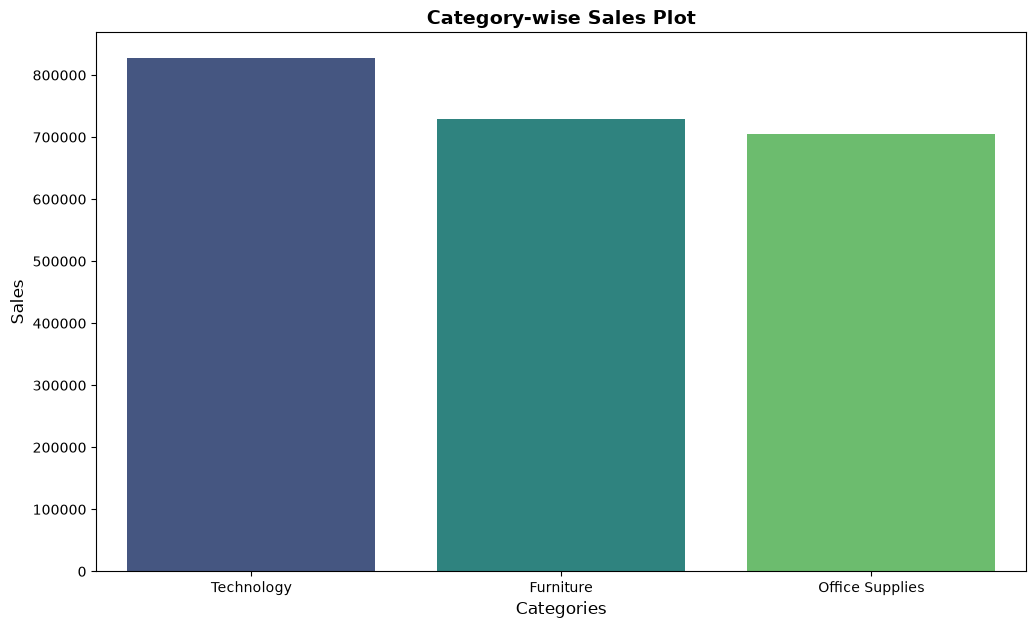

In [219]:
categorywise_sales = req_df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(12,7))
sns.barplot(categorywise_sales.sort_values(ascending=False),palette='viridis')
plt.title("Category-wise Sales Plot",fontsize=14, fontweight='bold')
plt.xlabel("Categories",fontsize=12)
plt.ylabel("Sales",fontsize=12)
plt.show()

In [220]:
req_cat = ['Furniture','Technology','Office Supplies']
req_reg = ['West','East']
multivariate_data = {}
for cat in req_cat:
    cat_df = req_df[req_df['Category'] == cat]
    multivariate_data[f"{cat}_sales"]=cat_df['Sales'].resample('ME').sum().fillna(0)
for reg in req_reg:
    reg_df = req_df[req_df['Region']==reg]
    multivariate_data[f"{reg}_sales"]=reg_df['Sales'].resample('ME').sum().fillna(0)
ts_df = pd.DataFrame(multivariate_data)
ts_df.head(10)

,Furniture_sales,Technology_sales,Office Supplies_sales,West_sales,East_sales
Order Date,,,,,
2015-01-31,6217.2770,3143.290,4845.140,2938.723,436.174
2015-02-28,1839.6580,1608.510,1071.724,1057.956,199.776
2015-03-31,14243.3680,32359.974,8602.455,11008.898,5458.176
2015-04-30,7944.8370,8973.144,10988.874,9070.357,3054.906
2015-05-31,6912.7870,9599.876,7131.640,6570.438,7250.103
2015-06-30,13144.5816,8435.965,12742.389,9629.422,10759.156
2015-07-31,10821.0510,7839.284,15121.208,21808.553,3403.296
2015-08-31,7125.2105,8937.050,11055.276,12742.949,4582.448
2015-09-30,23816.4808,30383.748,27423.298,14900.537,25292.789


In [221]:
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX

def forecast_features(feature_name,ts_df):
    
    # Run auto_arima with daily seasonality (m=12)
    auto_model = pm.auto_arima(
    ts_df[feature_name],
    seasonal=True,
    m=12,
    stepwise=True,
    trace=True,
    # error_action='ignore',
    suppress_warnings=True)
    # initializing SARIMAX model
    sari_model = SARIMAX(
        ts_df[feature_name],
        order=auto_model.order,
        seasonal_order=auto_model.seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_results = sari_model.fit()
    forecast_steps = 3 # for three months
    forecast_obj = sarima_results.get_forecast(steps=forecast_steps)
    forecast_mean = forecast_obj.predicted_mean
    confidence_intervals = forecast_obj.conf_int()
    
    # Build forecast DataFrame
    sarima_output = pd.DataFrame({
        'Date': pd.date_range(start=ts_df[feature_name].index[-1], periods=forecast_steps+1, freq='ME')[1:],
        'Predicted Sales': forecast_mean.values,
        'Lower Bound': confidence_intervals.iloc[:, 0].clip(lower=0).values,
        'Upper Bound': confidence_intervals.iloc[:, 1].values
    })
    
    # Add average row
    avg_row = pd.DataFrame({
        'Date': ['Average'],
        'Predicted Sales': [round(sarima_output['Predicted Sales'].mean(), 2)],
        'Lower Bound': [None],
        'Upper Bound': [None]
    })
    
    sarima_output = pd.concat([sarima_output, avg_row], ignore_index=True)
    # Display the forecast
    print("3-Months Sales Forecast (SARIMA):")
    display(sarima_output)
    # visualization
    forecast_periods = 3
    forecast = sarima_results.forecast(steps=forecast_periods)
    
    plt.figure(figsize=(10, 6))
    # Plot the historical observed data
    plt.plot(ts_df[feature_name].index, ts_df[feature_name], label='Observed')
    
    # Append the last historical point to the forecast to bridge the visual gap
    connect_index = ts_df[feature_name].index[-1:]
    connect_value = ts_df[feature_name].iloc[-1:]
    
    extended_forecast_index = connect_index.append(forecast.index)
    extended_forecast_values = pd.concat([connect_value, forecast])
    
    # 3. Plot the connected forecast line
    plt.plot(extended_forecast_index, extended_forecast_values, label='Forecast', color='red')
    
    plt.title("3-Month Sales Forecast")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.grid(True, alpha=0.3) # Adds a clean background grid for easier reading
    plt.legend()
    plt.show()

In [222]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_steps = 3
future_dates = pd.date_range(start=ts_df.index[-1], periods=forecast_steps + 1, freq='ME')[1:]

# Dictionary to store the final 3-month forecast results for every segment
all_forecasts = {'Date': future_dates}

# Loop through each column and fit an individual SARIMA model
for column_name in ts_df.columns:
    print(f"Training SARIMA for: {column_name}...")
    
    # Initialize SARIMA using your established auto_arima parameters
    # Note: Different categories might have different ideal parameters, 
    # but we use a robust seasonal baseline here.
    model = SARIMAX(
        ts_df[column_name],
        order=(2, 1, 0),
        seasonal_order=(1, 0, 0, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)
    
    # Extract the 3-month ahead predictions
    predictions = results.forecast(steps=forecast_steps)
    all_forecasts[column_name] = predictions.values

# Convert results dictionary into a final forecast DataFrame
final_forecast_matrix = pd.DataFrame(all_forecasts).set_index('Date')

print("\n=== 3-MONTH MULTI-SEGMENT SARIMA FORECAST ===")
display(final_forecast_matrix.round(2))

Training SARIMA for: Furniture_sales...
Training SARIMA for: Technology_sales...
Training SARIMA for: Office Supplies_sales...
Training SARIMA for: West_sales...
Training SARIMA for: East_sales...

=== 3-MONTH MULTI-SEGMENT SARIMA FORECAST ===


,Furniture_sales,Technology_sales,Office Supplies_sales,West_sales,East_sales
Date,,,,,
2019-01-31,11600.96,29071.20,24584.18,19717.91,21387.62
2019-02-28,10967.02,27583.63,21435.63,18725.38,10940.23
2019-03-31,11731.02,34239.16,22532.79,28904.19,18945.12


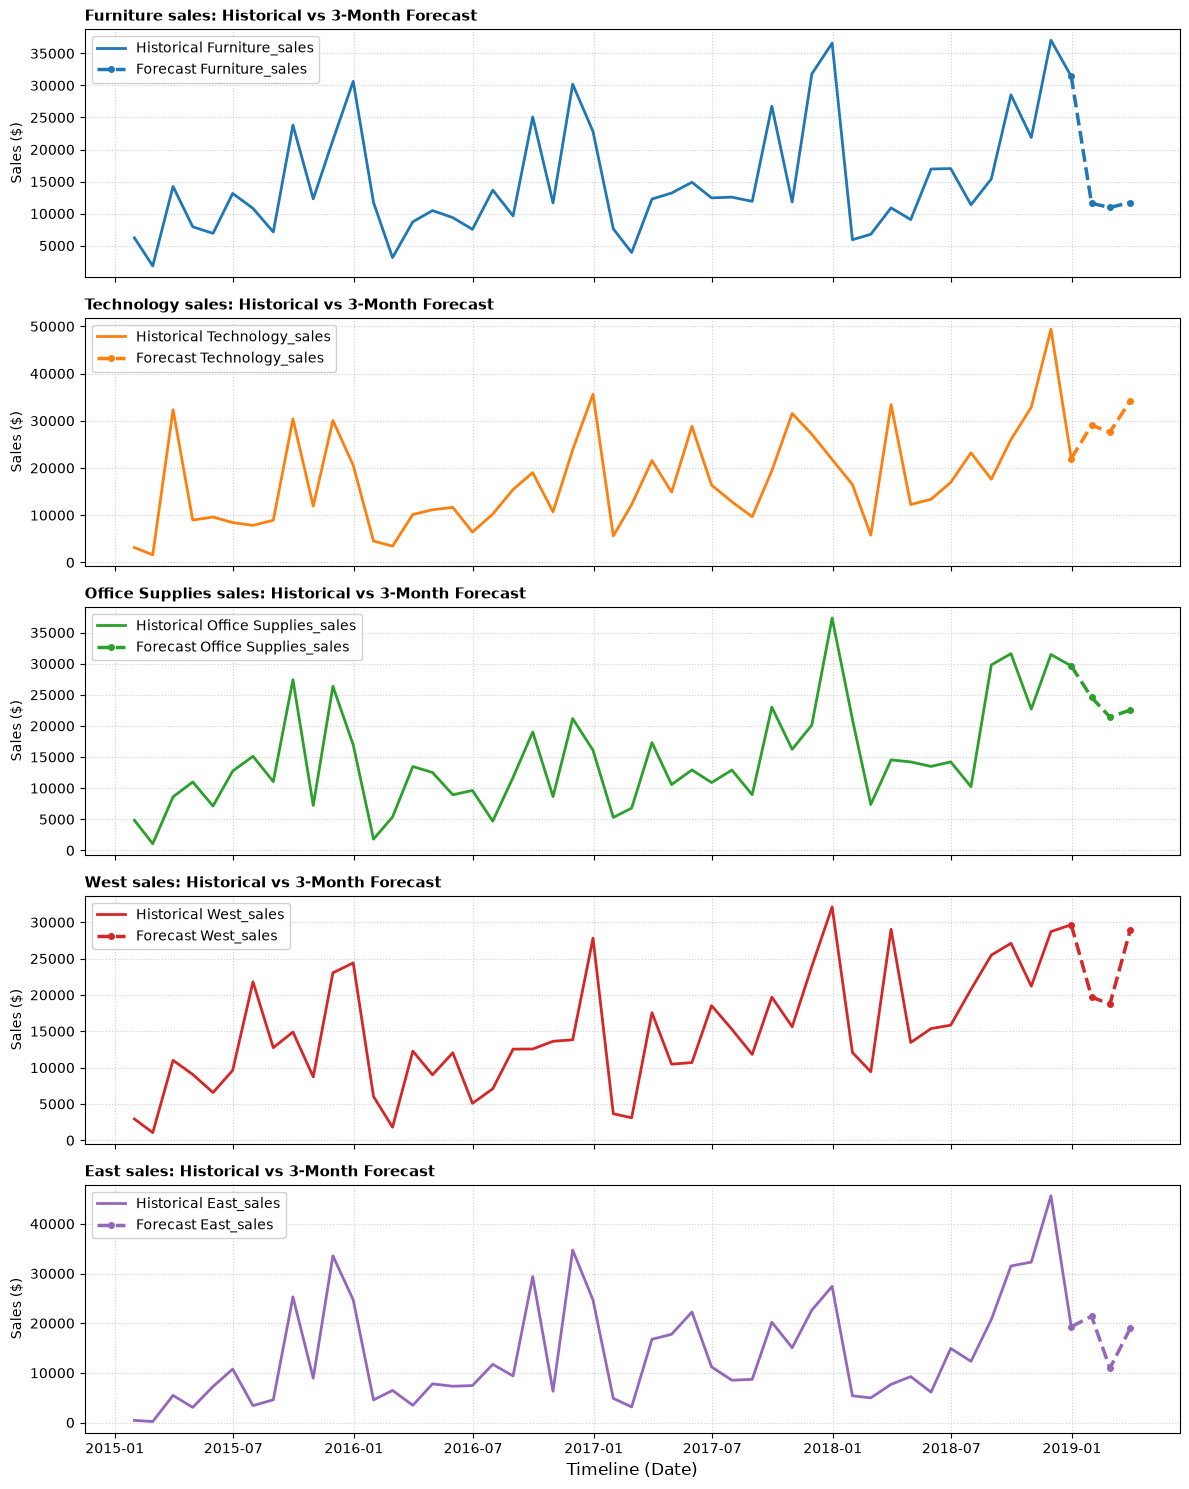

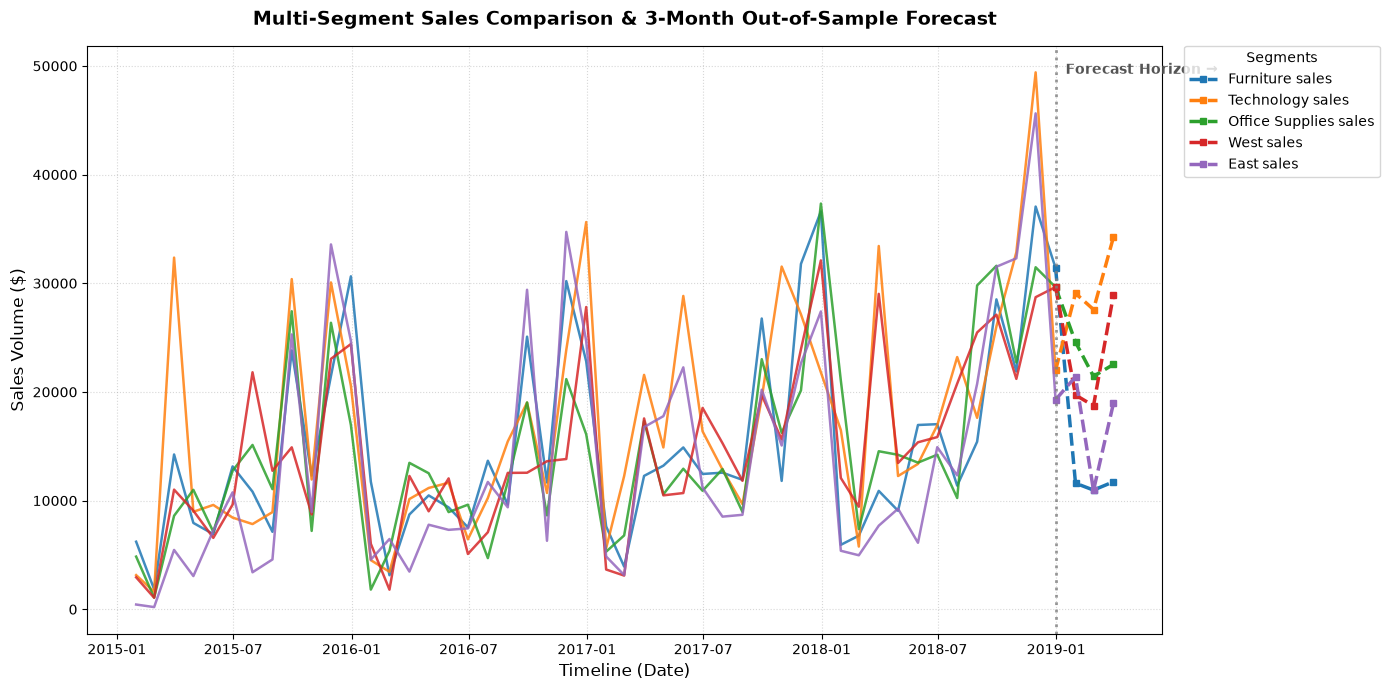

In [223]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. SETUP THE SEAMLESS VISUAL BRIDGE
# Connect the last historical data point to the forecast lines so they don't float detached
bridge_row = pd.DataFrame([ts_df.iloc[-1]], index=[ts_df.index[-1]])
full_combined_forecast = pd.concat([bridge_row, final_forecast_matrix])

# color palettes
colors = {
    'Furniture_sales': '#1f77b4',       # Muted Blue
    'Technology_sales': '#ff7f0e',      # Safety Orange
    'Office Supplies_sales': '#2ca02c', # Forest Green
    'West_sales': '#d62728',     # Brick Red
    'East_sales': '#9467bd'      # Deep Purple
}

segments = list(ts_df.columns)

# ==========================================
# VISUALIZATION 1: INDIVIDUAL SUBPLOTS (GRID)
# ==========================================
fig, axes = plt.subplots(nrows=len(segments), ncols=1, figsize=(12, 3 * len(segments)), sharex=True)

for ax, col in zip(axes, segments):
    # Plot historical segment data
    ax.plot(ts_df.index, ts_df[col], label=f'Historical {col}', color=colors[col], linewidth=2)
    # Plot 3-month forecast segment data
    ax.plot(full_combined_forecast.index, full_combined_forecast[col], 
            label=f'Forecast {col}', color=colors[col], linestyle='--', linewidth=2.5, marker='o', markersize=4)
    
    ax.set_title(f"{col.replace('_', ' ')}: Historical vs 3-Month Forecast", fontsize=11, fontweight='bold', loc='left')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
    ax.set_ylabel("Sales ($)")

plt.xlabel("Timeline (Date)", fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 2: COMBINED SINGLE PLOT
# ==========================================
plt.figure(figsize=(14, 7))

for col in segments:
    # Overlay historical lines
    plt.plot(ts_df.index, ts_df[col], color=colors[col], linewidth=1.8, alpha=0.85)
    # Overlay forecast lines (labeled for the legend)
    plt.plot(full_combined_forecast.index, full_combined_forecast[col], 
             label=col.replace('_', ' '), color=colors[col], linestyle='--', linewidth=2.5, marker='s', markersize=4)

# Draw a clean vertical marker line showing where history ends and forecast begins
plt.axvline(x=ts_df.index[-1], color='#7f7f7f', linestyle=':', linewidth=2, alpha=0.8)
plt.text(ts_df.index[-1], plt.ylim()[1] * 0.95, '  Forecast Horizon →', color='#555555', fontsize=10, fontweight='bold')

plt.title("Multi-Segment Sales Comparison & 3-Month Out-of-Sample Forecast", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Timeline (Date)", fontsize=12)
plt.ylabel("Sales Volume ($)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)

# Place legend cleanly outside the main graph area so it doesn't cover up any lines
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, frameon=True, title="Segments")
plt.tight_layout()
plt.show()

It is clear from our graph that the tecnology category is showing the strongest upcoming growth with consistent growing peaks and sales in West will perform much better than the sales in East region.

## Anomaly Detection in Sales Data
- Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern
- Mark the anomalies on a time series plot (use a different color/marker for anomaly points)
- For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")
- Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean
- Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?

In [224]:
vg_df = pd.read_csv("vgsales.csv")
vg_df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [225]:
vg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 1.4 MB


In [226]:
vg_df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [227]:
weekly_sales = pd.DataFrame(df['Sales'].resample('W').sum())
# weekly_sales.set_index('Order Date', inplace=True)
weekly_sales.reset_index(inplace=True)
weekly_sales

,Order Date,Sales
0,2015-01-04,304.5080
1,2015-01-11,4619.1080
2,2015-01-18,4130.5330
3,2015-01-25,3092.5440
4,2015-02-01,2527.9140
...,...,...
204,2018-12-02,35998.9000
205,2018-12-09,21537.2410
206,2018-12-16,11542.8340
207,2018-12-23,19457.0680


In [228]:
weekly_sales['Order_Year'] = weekly_sales['Order Date'].dt.year

In [229]:
weekly_sales 

,Order Date,Sales,Order_Year
0,2015-01-04,304.5080,2015
1,2015-01-11,4619.1080,2015
2,2015-01-18,4130.5330,2015
3,2015-01-25,3092.5440,2015
4,2015-02-01,2527.9140,2015
...,...,...,...
204,2018-12-02,35998.9000,2018
205,2018-12-09,21537.2410,2018
206,2018-12-16,11542.8340,2018
207,2018-12-23,19457.0680,2018


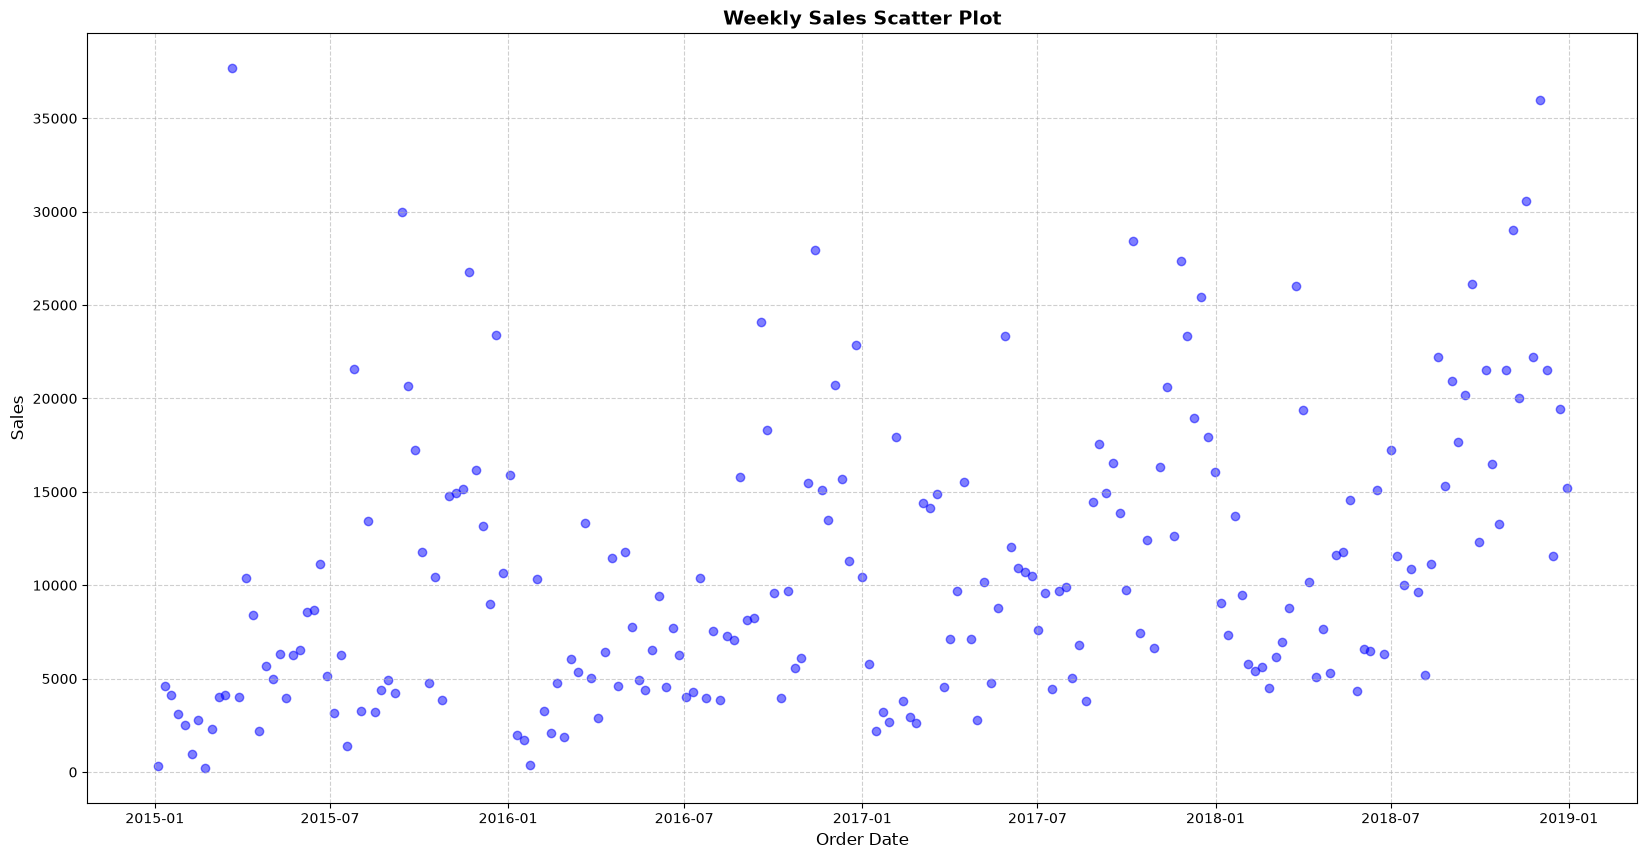

In [230]:
plt.scatter(weekly_sales['Order Date'], weekly_sales['Sales'], color='blue', alpha=0.5)
plt.title('Weekly Sales Scatter Plot', fontsize=14, fontweight='bold')
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

In [231]:
from sklearn.ensemble import IsolationForest
# initialize and fit the model
clf = IsolationForest(contamination=0.05, random_state=42)
clf.fit(weekly_sales.select_dtypes(include=[np.number]))  
predictions = clf.predict(weekly_sales.select_dtypes(include=[np.number]))

In [232]:
predictions

array([ 1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1, -1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,
       -1,  1,  1,  1,  1])

In [233]:
import numpy as np
abn_ind = np.where(predictions < 0)
abn_ind

(array([  7,  11,  36,  46,  50,  55,  97, 144, 200, 202, 204]),)

In [234]:
x = np.array(weekly_sales['Sales'])

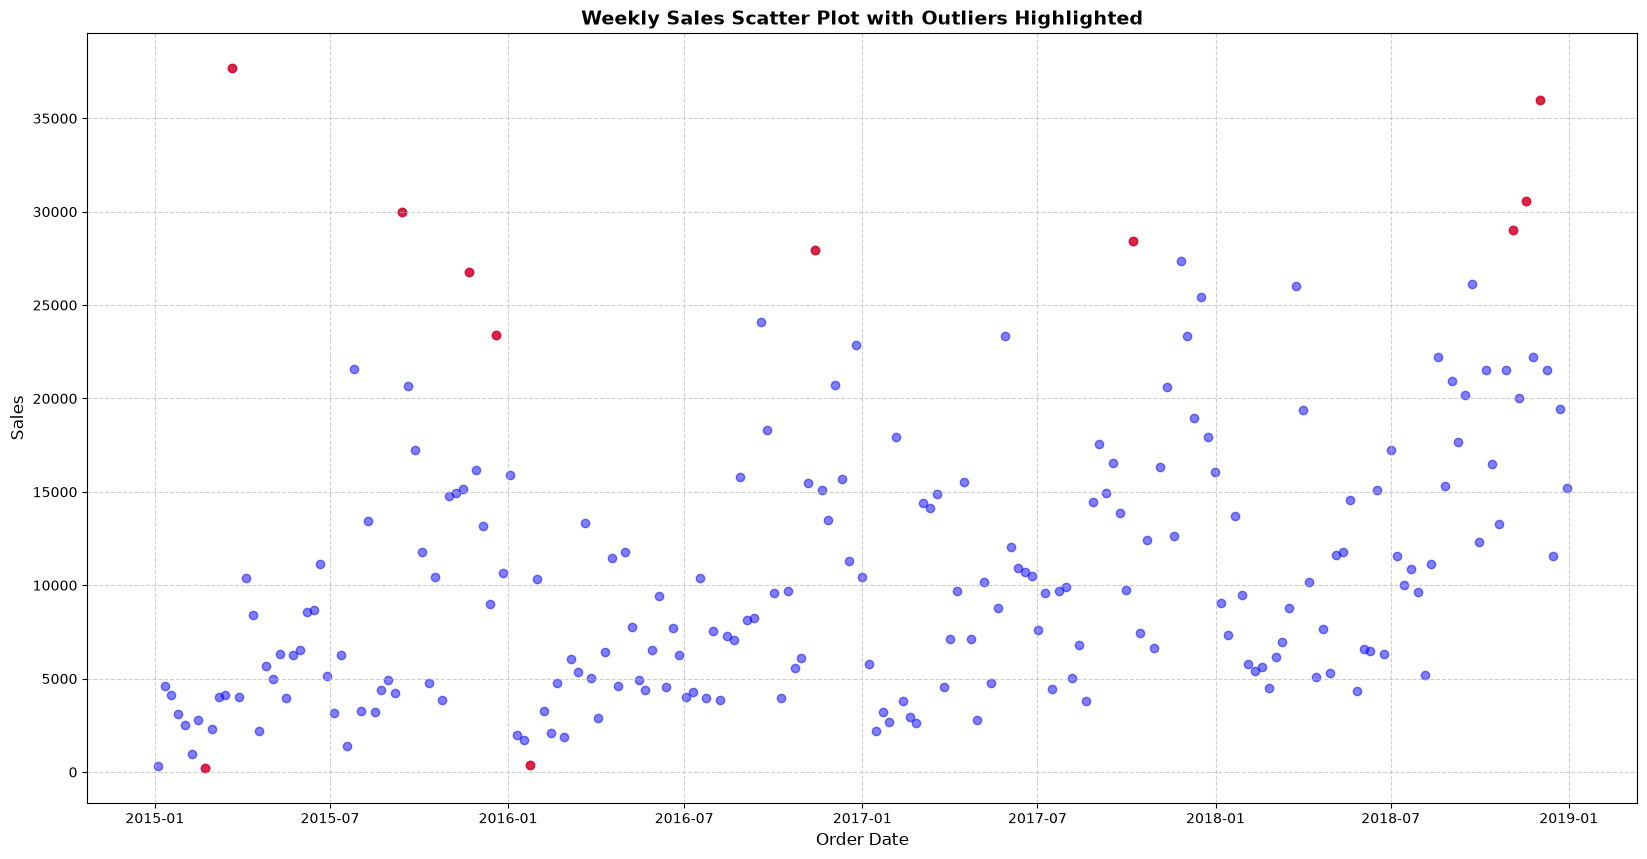

In [235]:
plt.scatter(weekly_sales['Order Date'], weekly_sales['Sales'], color='blue', alpha=0.5)
plt.scatter(weekly_sales.iloc[abn_ind]['Order Date'], weekly_sales.iloc[abn_ind]['Sales'], color='red', alpha=0.7)
plt.title('Weekly Sales Scatter Plot with Outliers Highlighted', fontsize=14, fontweight='bold')
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

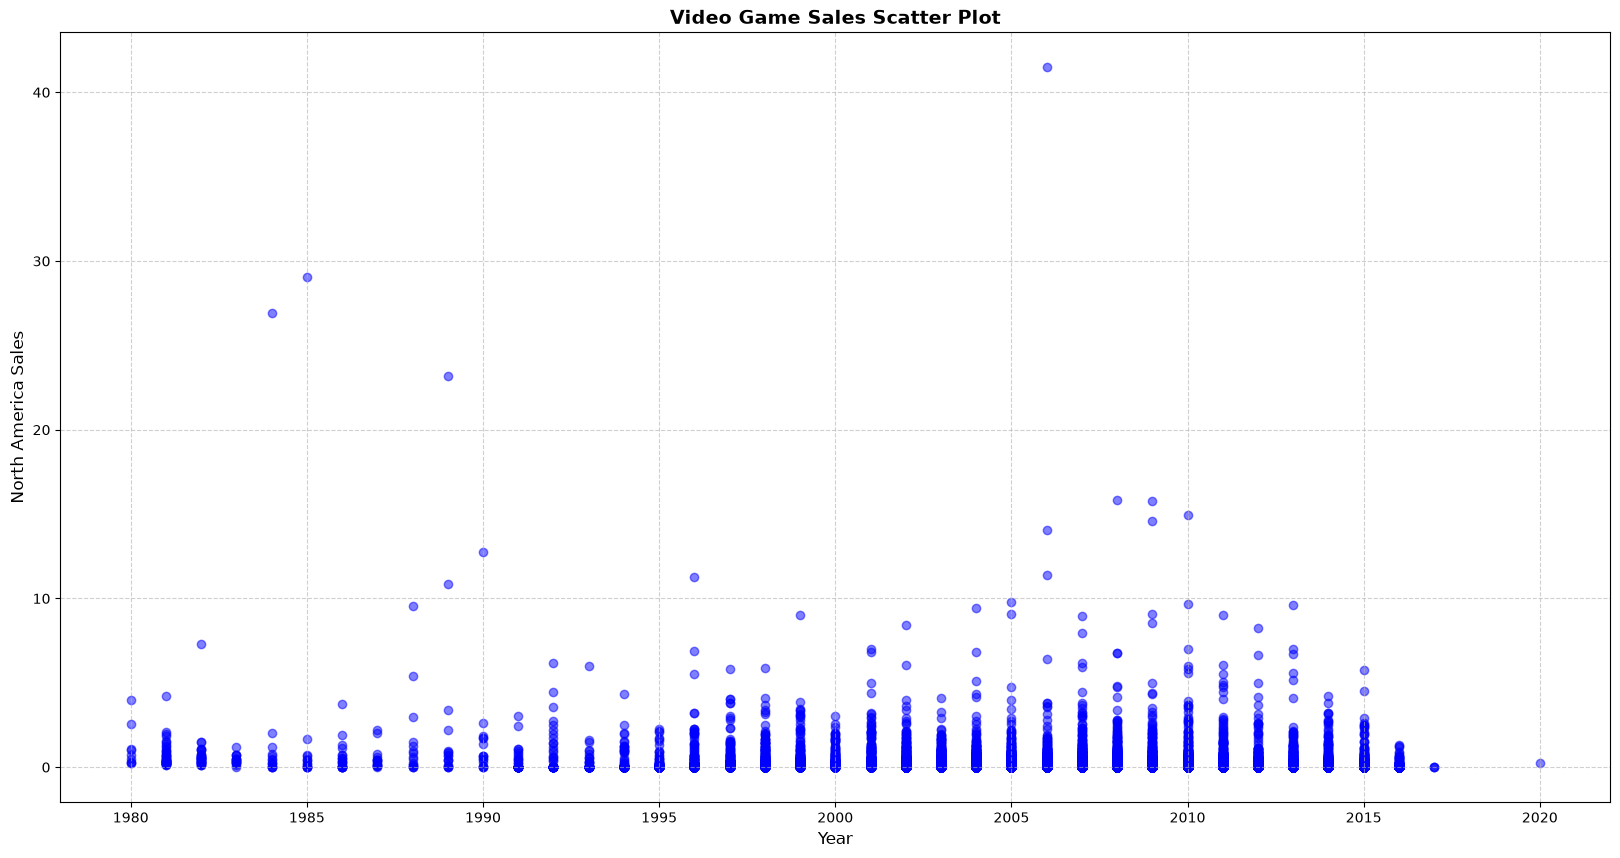

In [236]:
plt.scatter(vg_df['Year'], vg_df['NA_Sales'], color='blue', alpha=0.5)
plt.title('Video Game Sales Scatter Plot', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('North America Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [237]:
vg_df_simple = vg_df.drop(columns=['Rank', 'Name', 'Platform', 'Genre', 'Publisher', 'Other_Sales','EU_Sales','JP_Sales','Global_Sales'])
vg_df_simple.sort_values(by='Year', inplace=True)

In [238]:
vg_df_simple

,Year,NA_Sales
544,1980.0,2.56
6896,1980.0,0.22
4025,1980.0,0.46
6317,1980.0,0.25
1969,1980.0,0.99
...,...,...
16307,NaN,0.01
16327,NaN,0.01
16366,NaN,0.01
16427,NaN,0.01


In [239]:
vg_df_simple.dropna(inplace=True)
vg_df_simple.reset_index(inplace=True,drop=True)
vg_df_simple

,Year,NA_Sales
0,1980.0,2.56
1,1980.0,0.22
2,1980.0,0.46
3,1980.0,0.25
4,1980.0,0.99
...,...,...
16322,2016.0,0.01
16323,2017.0,0.00
16324,2017.0,0.00
16325,2017.0,0.00


In [240]:
selected_vg_df = vg_df_simple[(vg_df_simple['Year'] >= 2015) & (vg_df_simple['Year'] < 2020)]

In [241]:
selected_vg_df = selected_vg_df.rename(columns={'NA_Sales': 'Sales', 'Year': 'Order_Year'})

In [242]:
selected_vg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 961 entries, 15365 to 16325
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order_Year  961 non-null    float64
 1   Sales       961 non-null    float64
dtypes: float64(2)
memory usage: 15.1 KB


In [243]:
clf_2 = IsolationForest(contamination=0.05, random_state=42)
clf_2.fit(selected_vg_df['Sales'].values.reshape(-1, 1))  # Reshape to 2D array for fitting  
predictions_2 = clf_2.predict(selected_vg_df['Sales'].values.reshape(-1, 1))  # Reshape to 2D array for predictions

In [244]:
x = np.array(selected_vg_df['Sales'])
x

array([0.  , 0.  , 0.  , 0.  , 0.86, 0.  , 0.  , 0.  , 0.  , 0.08, 1.18,
       0.16, 0.1 , 0.  , 0.09, 0.  , 0.  , 0.  , 0.02, 0.08, 0.04, 0.  ,
       0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.72,
       0.01, 0.52, 0.5 , 0.  , 0.66, 0.77, 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.03, 0.1 , 0.01, 0.  , 0.46, 0.  , 0.41, 0.  , 2.93, 1.11, 0.02,
       0.08, 0.09, 0.07, 0.03, 0.  , 0.  , 0.  , 0.07, 0.  , 0.  , 0.04,
       0.  , 0.  , 0.3 , 0.  , 0.36, 0.52, 0.  , 0.32, 0.01, 0.  , 0.71,
       0.69, 0.82, 0.  , 0.  , 0.17, 0.  , 0.  , 0.  , 2.47, 0.  , 4.52,
       0.06, 0.  , 0.03, 0.02, 0.  , 0.  , 0.  , 0.08, 0.  , 0.  , 0.63,
       0.35, 0.  , 0.47, 0.  , 0.77, 0.37, 0.82, 0.  , 0.44, 0.  , 0.  ,
       0.  , 0.  , 0.46, 0.67, 0.34, 0.  , 0.  , 0.  , 0.  , 0.  , 0.03,
       0.  , 0.  , 0.07, 0.04, 0.  , 0.  , 0.08, 0.04, 0.03, 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.42, 0.02, 0.  , 0.  , 0.32, 0.02,
       0.55, 0.66, 0.61, 0.36, 0.36, 0.  , 0.  , 0.

In [245]:
predictions_2

array([ 1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,  1,
       -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [246]:
abn_ind_2 = np.where(predictions_2 < 0)
abn_ind_2

(array([  4,  10,  23,  32,  38,  52,  53,  76,  77,  78,  85,  87, 103,
        105, 113, 179, 191, 241, 297, 298, 334, 348, 360, 404, 405, 417,
        425, 426, 446, 457, 503, 523, 551, 560, 581, 589, 590, 594, 613,
        705, 769, 797, 838, 854, 856, 919, 927]),)

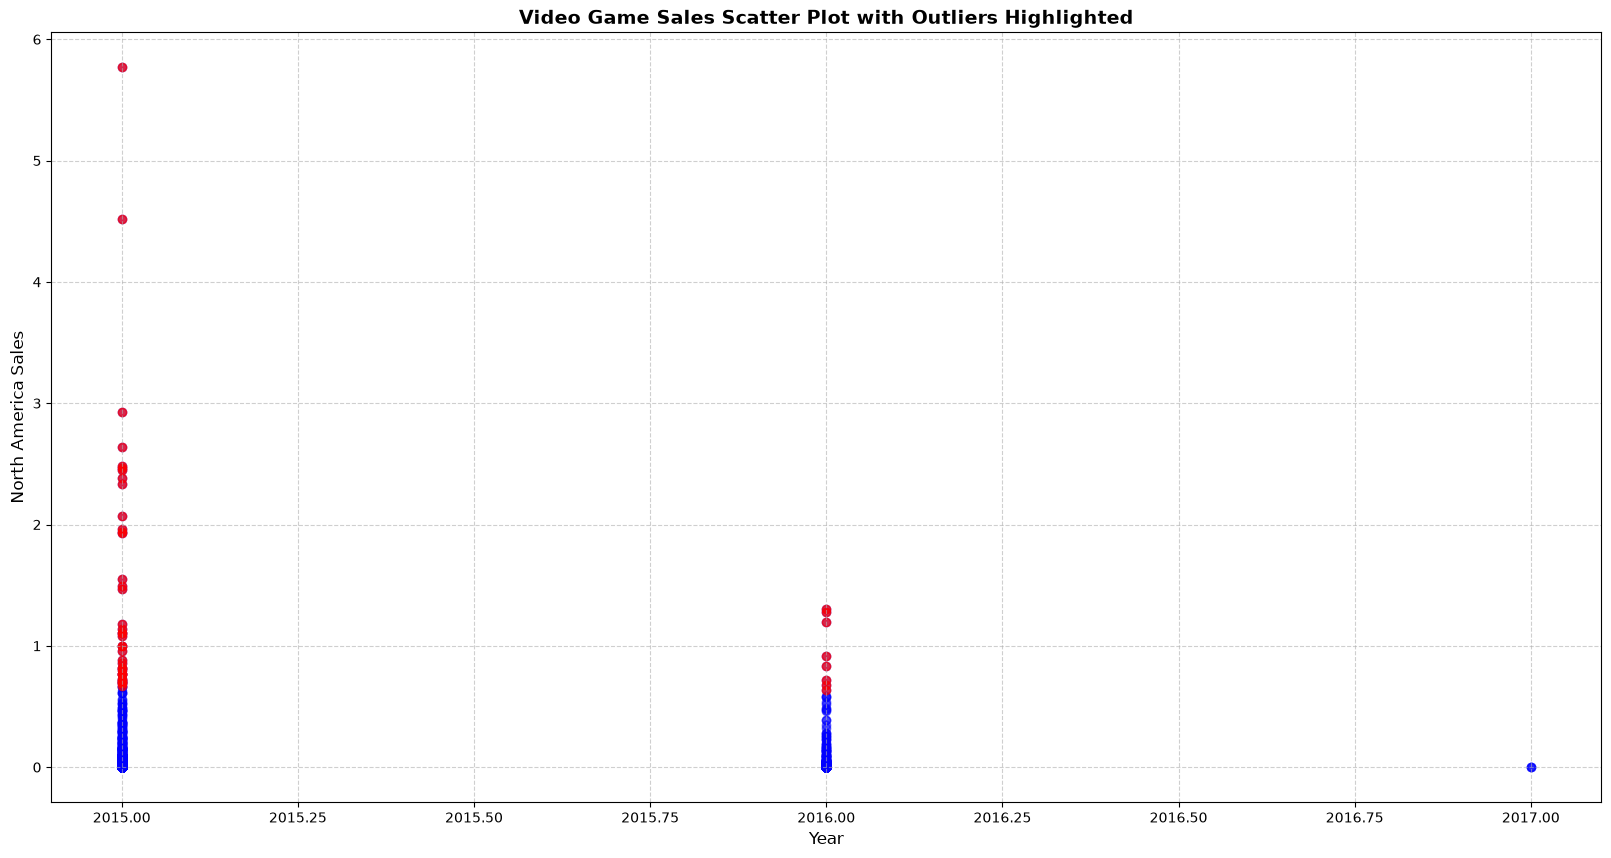

In [247]:
plt.scatter(selected_vg_df['Order_Year'], selected_vg_df['Sales'], color='blue', alpha=0.5)
plt.scatter(selected_vg_df.iloc[abn_ind_2]['Order_Year'], selected_vg_df.iloc[abn_ind_2]['Sales'], color='red', alpha=0.7)
plt.title('Video Game Sales Scatter Plot with Outliers Highlighted', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('North America Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [248]:
selected_weekly_sales = weekly_sales.drop(columns='Order Date')
selected_weekly_sales 

,Sales,Order_Year
0,304.5080,2015
1,4619.1080,2015
2,4130.5330,2015
3,3092.5440,2015
4,2527.9140,2015
...,...,...
204,35998.9000,2018
205,21537.2410,2018
206,11542.8340,2018
207,19457.0680,2018


In [249]:
anomalous_df = pd.merge(selected_weekly_sales, selected_vg_df, how='outer', on=['Order_Year', 'Sales'])
anomalous_df.sort_values(by='Order_Year', inplace=True)
anomalous_df.reset_index(inplace=True, drop=True)
anomalous_df

,Sales,Order_Year
0,0.000,2015.0
1,0.000,2015.0
2,0.000,2015.0
3,0.000,2015.0
4,0.000,2015.0
...,...,...
1165,26029.904,2018.0
1166,26104.433,2018.0
1167,29017.467,2018.0
1168,30572.447,2018.0


In [250]:
isof_clf = IsolationForest(contamination=0.025, random_state=42)
isof_clf.fit(anomalous_df['Sales'].values.reshape(-1, 1))  # Reshape to 2D array for fitting  
prediction = isof_clf.predict(anomalous_df['Sales'].values.reshape(-1, 1))  # Reshape to 2D array for predictions

In [261]:
abnormal_indices = np.where(prediction < 0)
print(abnormal_indices)

(array([ 614,  615,  616,  661,  662,  663,  664,  665, 1010, 1059, 1060,
       1061, 1113, 1114, 1115, 1116, 1117, 1155, 1156, 1158, 1160, 1161,
       1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169]),)


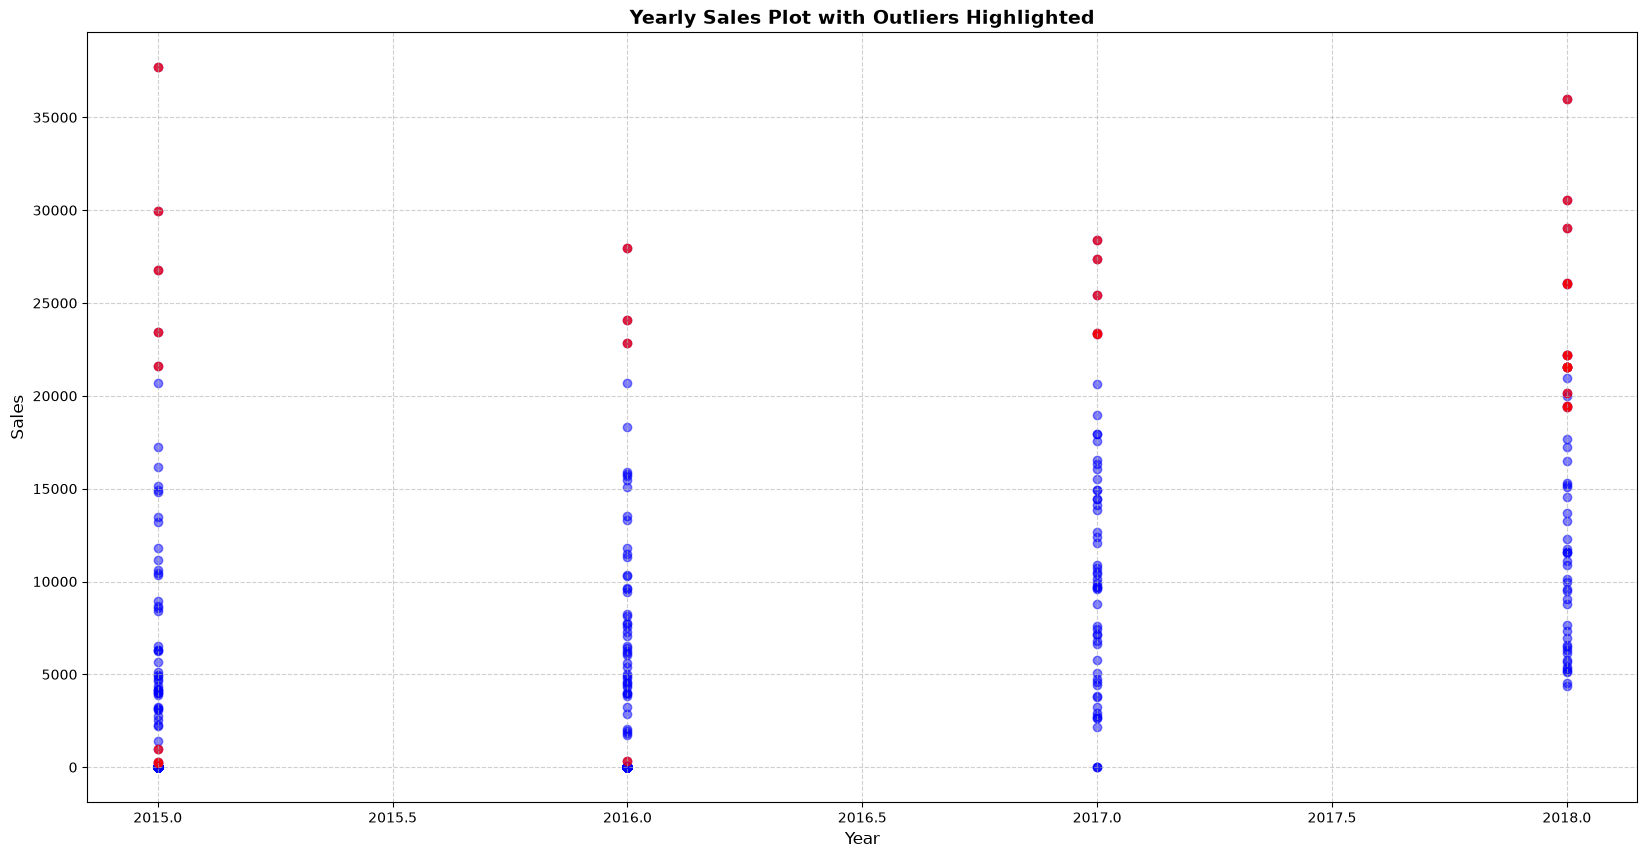

In [252]:
plt.scatter(anomalous_df['Order_Year'], anomalous_df['Sales'], color='blue', alpha=0.5)
plt.scatter(anomalous_df.iloc[abnormal_indices]['Order_Year'], anomalous_df.iloc[abnormal_indices]['Sales'], color='red', alpha=0.7)
plt.title('Yearly Sales Plot with Outliers Highlighted', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [253]:
from scipy.stats import zscore
anomalous_df['Z-score'] = zscore(anomalous_df['Sales'])
print(anomalous_df)

          Sales  Order_Year   Z-score
0         0.000      2015.0 -0.372544
1         0.000      2015.0 -0.372544
2         0.000      2015.0 -0.372544
3         0.000      2015.0 -0.372544
4         0.000      2015.0 -0.372544
...         ...         ...       ...
1165  26029.904      2018.0  4.644038
1166  26104.433      2018.0  4.658402
1167  29017.467      2018.0  5.219813
1168  30572.447      2018.0  5.519494
1169  35998.900      2018.0  6.565301

[1170 rows x 3 columns]


In [254]:
# normally considered outliers are either above 3 or below -3
outliers = anomalous_df[anomalous_df['Z-score'].abs() > 3]
print(outliers)
print(outliers.shape)

           Sales  Order_Year   Z-score
660   20685.8320      2015.0  3.614108
661   21590.0800      2015.0  3.788379
662   23416.4530      2015.0  4.140364
663   26793.6235      2015.0  4.791225
664   29959.1370      2015.0  5.401295
665   37703.6650      2015.0  6.893850
1057  18316.3650      2016.0  3.157456
1058  20712.1000      2016.0  3.619171
1059  22843.0470      2016.0  4.029855
1060  24095.9600      2016.0  4.271321
1061  27965.3492      2016.0  5.017045
1108  17558.9918      2017.0  3.011492
1109  17926.3680      2017.0  3.082294
1110  17948.2470      2017.0  3.086511
1111  18961.0020      2017.0  3.281693
1112  20640.3020      2017.0  3.605334
1113  23324.7620      2017.0  4.122693
1114  23367.6620      2017.0  4.130961
1115  25449.8000      2017.0  4.532238
1116  27367.7160      2017.0  4.901866
1117  28412.0980      2017.0  5.103144
1154  17672.0480      2018.0  3.033281
1155  19382.9038      2018.0  3.363003
1156  19457.0680      2018.0  3.377296
1157  20015.5500      201

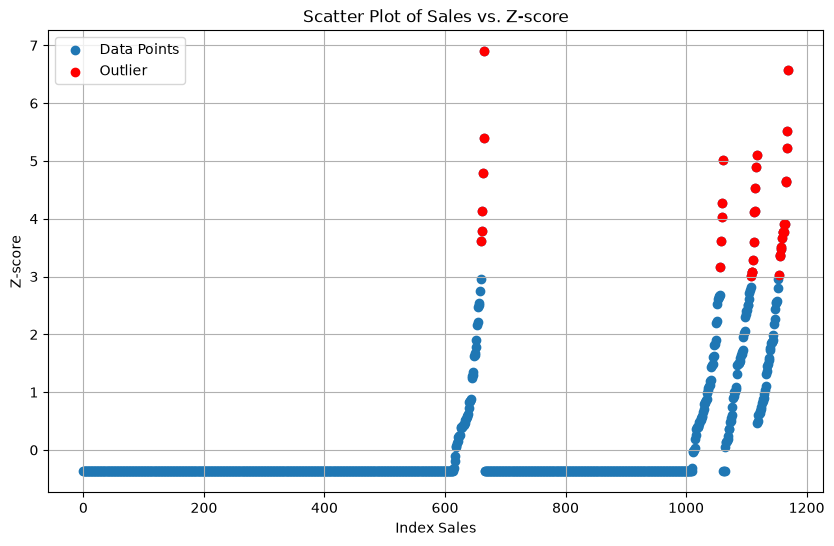

In [265]:
plt.figure(figsize=(10, 6))

plt.scatter(anomalous_df['Sales'].index, anomalous_df['Z-score'], label='Data Points')
plt.scatter(outliers['Sales'].index, outliers['Z-score'], color='red', label='Outlier')

plt.xlabel('Index Sales')
plt.ylabel('Z-score')
plt.title('Scatter Plot of Sales vs. Z-score')
plt.legend()
plt.grid(True)
plt.show()

## Product Demand Segmentation using Clustering
- Aggregate data at the product sub-category level with features like:
    - Total sales volume
    - Sales growth rate (year-over-year)
    - Sales volatility (standard deviation of monthly sales)
    - Average order value
- Apply K-Means Clustering to segment products into demand groups
- Use the Elbow Method to find the optimal number of clusters
- Label each cluster meaningfully, for example:
    - High Volume, Stable Demand
    - Low Volume, High Volatility
    - Growing Demand
    - Declining Demand
- Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)
- Write: what stocking strategy would you recommend for each cluster?

In [255]:
df.head()

,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,...,Order_Month,Order_Week_Number,Order_Day_of_Week,Order_Quarter,Ship_Year,Ship_Month,Ship_Week_Number,Ship_Day_of_Week,Ship_Quarter,Days_to_Ship
Order Date,,,,,,,,,,,,,,,,,,,,,
2015-01-03,CA-2015-103800,2015-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095.0,...,1,1,5,1,2015,1,2,2,1,4
2015-01-04,CA-2015-112326,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,...,1,1,6,1,2015,1,2,3,1,4
2015-01-04,CA-2015-112326,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,...,1,1,6,1,2015,1,2,3,1,4
2015-01-04,CA-2015-112326,2015-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540.0,...,1,1,6,1,2015,1,2,3,1,4
2015-01-05,CA-2015-141817,2015-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143.0,...,1,2,0,1,2015,1,3,0,1,7


In [256]:
import pandas as pd
import numpy as np

# ==========================================================
# STEP 1: Total Volume & Average Order Value (AOV)
# ==========================================================
# Group directly by the Sub-Category column
base_metrics = df.groupby('Sub-Category').agg(
    Total_Sales_Volume=('Sales', 'sum'),
    Total_Orders=('Order ID', 'nunique')
).reset_index()

# Calculate AOV
base_metrics['Average_Order_Value'] = base_metrics['Total_Sales_Volume'] / base_metrics['Total_Orders']
base_metrics.drop(columns=['Total_Orders'], inplace=True)


# ==========================================================
# STEP 2: Volatility (Standard Deviation of Monthly Sales)
# ==========================================================
# Use pd.Grouper on the index by specifying level=0
monthly_subcat = df.groupby([pd.Grouper(level=0, freq='ME'), 'Sub-Category'])['Sales'].sum().unstack(fill_value=0)

# Calculate standard deviation across months
volatility_series = monthly_subcat.std(axis=0).to_frame(name='Sales_Volatility')


# ==========================================================
# STEP 3: YoY Sales Growth Rate
# ==========================================================
# Group by the year attribute directly from the index (.index.year)
annual_sales = df.groupby([df.index.year, 'Sub-Category'])['Sales'].sum().unstack(fill_value=0)

# Identify the last two years dynamically
available_years = sorted(annual_sales.index)
current_year = available_years[-1]
previous_year = available_years[-2]

# Calculate YoY Growth rate percentage
yoy_growth = ((annual_sales.loc[current_year] - annual_sales.loc[previous_year]) / annual_sales.loc[previous_year]) * 100
yoy_growth_series = yoy_growth.to_frame(name='YoY_Sales_Growth_Rate_Pct')


# ==========================================================
# STEP 4: Final Feature Consolidation
# ==========================================================
product_profile_df = base_metrics.merge(volatility_series, left_on='Sub-Category', right_index=True)
product_profile_df = product_profile_df.merge(yoy_growth_series, left_on='Sub-Category', right_index=True)

# Set the sub-category as the final dataframe index
product_profile_df.set_index('Sub-Category', inplace=True)

print(f"=== SUB-CATEGORY PROFILING MATRIX (YoY Growth: {previous_year} vs {current_year}) ===")
display(product_profile_df.round(2))

=== SUB-CATEGORY PROFILING MATRIX (YoY Growth: 2017 vs 2018) ===


,Total_Sales_Volume,Average_Order_Value,Sales_Volatility,YoY_Sales_Growth_Rate_Pct
Sub-Category,,,,
Accessories,164186.70,233.88,2579.99,39.55
Appliances,104618.40,235.63,1821.62,54.56
Art,26705.41,37.09,330.49,49.83
Binders,200028.78,154.94,3848.22,46.39
Bookcases,113813.20,512.67,2229.36,14.27
Chairs,322822.73,570.36,4407.23,13.74
Copiers,146248.09,2215.88,4969.72,35.79
Envelopes,16128.05,66.37,234.27,-24.19
Fasteners,3001.96,14.16,49.09,-9.64


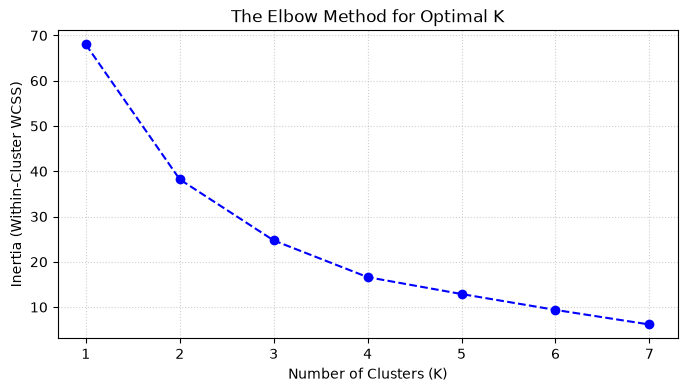


=== CLUSTER PROFILE AVERAGES (Inspect this to map labels!) ===


,Total_Sales_Volume,Average_Order_Value,Sales_Volatility,YoY_Sales_Growth_Rate_Pct
Cluster,,,,
0,238290.66,977.18,4340.38,-2.72
1,237015.27,1312.04,4511.22,35.00
2,89386.19,167.09,1540.23,23.06


In [257]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 1: Scale the Data for K-Means
# ==========================================
scaler = StandardScaler()
# Using the dataframe created in the previous task
features = ['Total_Sales_Volume', 'Average_Order_Value', 'Sales_Volatility', 'YoY_Sales_Growth_Rate_Pct']
scaled_features = scaler.fit_transform(product_profile_df[features])

# ==========================================
# STEP 2: The Elbow Method
# ==========================================
inertia = []
k_range = range(1, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster WCSS)')
plt.title('The Elbow Method for Optimal K')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# ==========================================
# STEP 3: Apply Optimal K-Means (Assuming K=4 from Elbow)
# ==========================================
optimal_k = 4  # Adjust this based on your actual elbow plot output!
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
product_profile_df['Cluster'] = kmeans_final.fit_transform(scaled_features).argmax(axis=1) # assigns 0, 1, 2, 3

# ==========================================
# STEP 4: Profile the Cluster Centroids (The Logic Check)
# ==========================================
print("\n=== CLUSTER PROFILE AVERAGES (Inspect this to map labels!) ===")
cluster_profiles = product_profile_df.groupby('Cluster')[features].mean()
display(cluster_profiles.round(2))

In [258]:
# Create your business mapping dictionary based on the centroid output table
cluster_label_mapping = {
    0: "High Volume, Stable Demand",
    1: "Low Volume, High Volatility",
    2: "Growing Demand",
    3: "Declining Demand"
}

# Apply labels to the dataset
product_profile_df['Demand_Group'] = product_profile_df['Cluster'].map(cluster_label_mapping)

print("\n=== FINAL PRODUCT DEMAND SEGMENTATION ===")
display(product_profile_df[['Demand_Group'] + features].head())


=== FINAL PRODUCT DEMAND SEGMENTATION ===


,Demand_Group,Total_Sales_Volume,Average_Order_Value,Sales_Volatility,YoY_Sales_Growth_Rate_Pct
Sub-Category,,,,,
Accessories,Growing Demand,164186.7000,233.884188,2579.994809,39.548250
Appliances,Growing Demand,104618.4030,235.627034,1821.621539,54.564520
Art,Growing Demand,26705.4100,37.090847,330.488343,49.825485
Binders,Growing Demand,200028.7850,154.940964,3848.223648,46.386288
Bookcases,Growing Demand,113813.1987,512.672066,2229.359867,14.267352


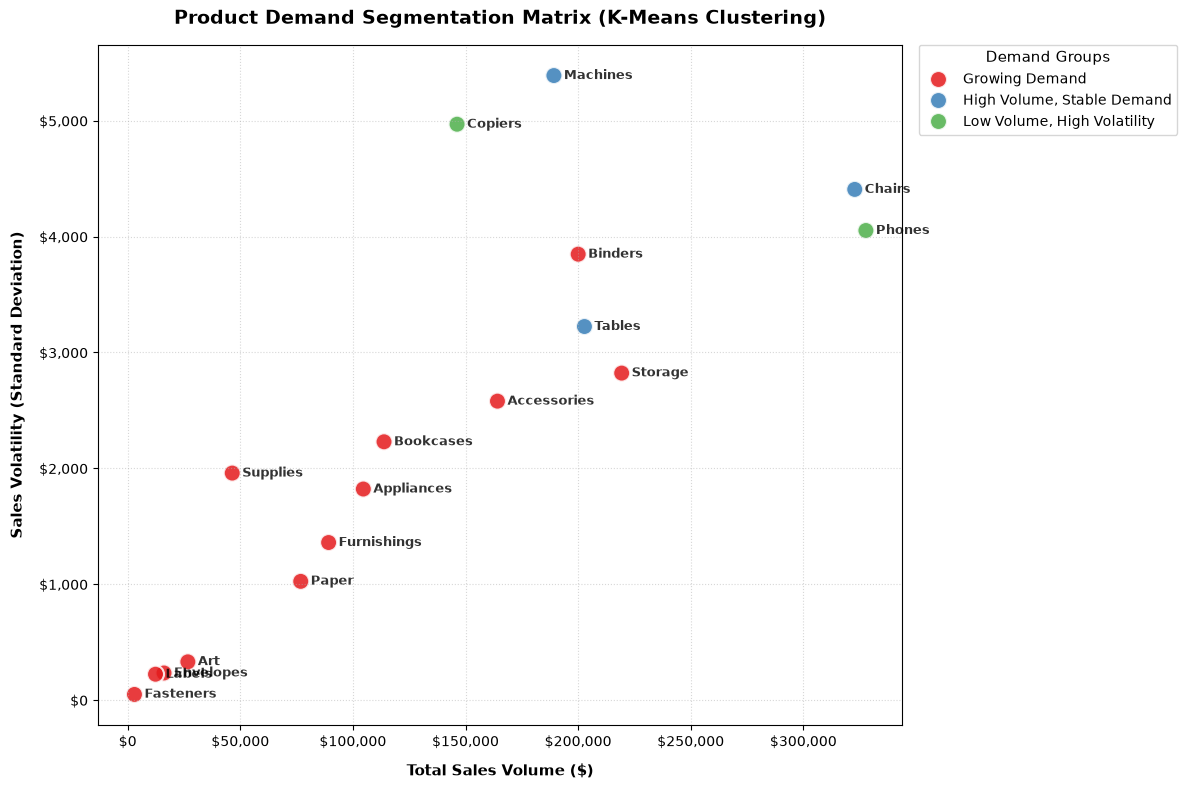

In [259]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# 1. Create a vibrant color palette mapped directly to your business labels
# (Using a distinct hue for each of your descriptive groups)
unique_labels = product_profile_df['Demand_Group'].unique()
palette = sns.color_palette("Set1", len(unique_labels))
color_map = dict(zip(unique_labels, palette))

# 2. Draw the scatter plot using Seaborn
sns.scatterplot(
    data=product_profile_df,
    x='Total_Sales_Volume',
    y='Sales_Volatility',
    hue='Demand_Group',
    palette=color_map,
    s=150,                  # Make the data points large and legible
    alpha=0.85,             # Add slight transparency to see overlapping points
    edgecolor='w',          # Crisp white borders around points
    linewidth=1.5
)

# 3. Dynamic Text Annotation (Labels each point with its Sub-Category name)
# This prevents you from having to guess which dot is which product!
for sub_category, row in product_profile_df.iterrows():
    plt.text(
        x=row['Total_Sales_Volume'],
        y=row['Sales_Volatility'],
        s=f"  {sub_category}", # Adds a small space so the text doesn't touch the dot
        fontsize=9,
        fontweight='semibold',
        alpha=0.8,
        va='center'            # Vertically aligns text with the center of the point
    )

# 4. Polish and Format the Visualization
plt.title("Product Demand Segmentation Matrix (K-Means Clustering)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Total Sales Volume ($)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Sales Volatility (Standard Deviation)", fontsize=11, fontweight='bold', labelpad=10)

# Apply dollar formatting to the axes ticks for clean presentation
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))

# Place the legend neatly outside the graph so it doesn't cover up any data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title="Demand Groups", title_fontsize='11')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Stocking strategies for each product:
1. Place these high volume, stable demand items in the Golden Zone (easily accessible, near shipping docks) because they turn over constantly.
2. For low volumne high volatility items Periodic Review Policy with Just-In-Time (JIT) Overtones, is the way.
3. For products in growing demand clusters/category Aggressive Forward-Buying & Dynamic Safety Stock is suitable.